# Module C Milestone 1: Data Science Capstone
## Week 1 — Feature Engineering, Multicollinearity, and Modeling

**Objective:**
This notebook is the exploratory evidence base for the Milestone 1 Summary Document. It implements all Week 1 concepts: polynomial early stopping (AUC-ROC based), mean-centered interaction terms, stepwise VIF filtering, and a complete sequential pipeline applied to all three project datasets.

**Primary Dataset**: Credit Card Fraud (`is_fraud`, ~0.6% fraud rate)
**Breadth Datasets**: Credit Approval (`Status`) | Loan Default (`Default`)
**Primary Metric**: AUC-ROC — accuracy is misleading under class imbalance.

In [1]:
# ============================================================
# ALL IMPORTS — loaded once here, never repeated below
# ============================================================
import contextlib, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             f1_score, recall_score,
                             classification_report, precision_recall_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14

DATA_DIR = r"E:\BU\CDSDX 699 O2\data"
print("All libraries loaded successfully.")

All libraries loaded successfully.


### 1. Data Loading & Initial Inspection (EDA)
We load the primary pre-split fraud datasets. Maintaining the pre-split structure simulates a real production deployment where the model never sees future data during training. The first diagnostic after loading is **class balance** — this directly drives our choice to use AUC-ROC over accuracy.

FRAUD  [1/10]  Load & Initial EDA
Train shape: (1296675, 35)  |  Test shape: (555719, 35)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,0,0,0,0,1,0,0,0,0,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1,0,0,0,0,0,0,0,0,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,0,0,0,0,0,0,0,0,0,0



Class Distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Fraud Rate: 0.0058  (0.58%)

=> AUC-ROC is the primary metric — accuracy is misleading at ~0.6% fraud rate.


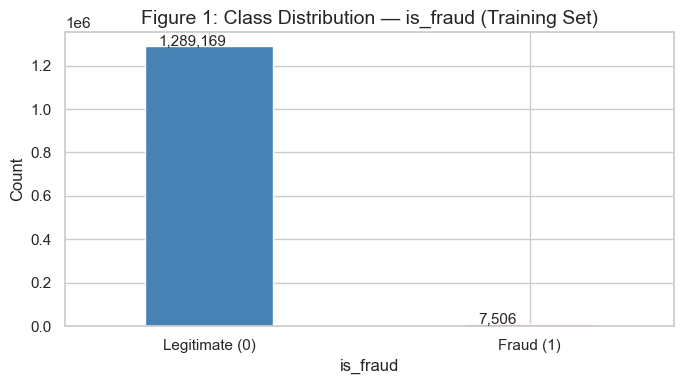

In [2]:
fraud_train_df = pd.read_csv(f"{DATA_DIR}\\fraud_train_processed.csv")
fraud_test_df  = pd.read_csv(f"{DATA_DIR}\\fraud_test_processed.csv")

print("=" * 65)
print("FRAUD  [1/10]  Load & Initial EDA")
print("=" * 65)
print(f"Train shape: {fraud_train_df.shape}  |  Test shape: {fraud_test_df.shape}")
display(fraud_train_df.head(3))

fraud_rate = fraud_train_df["is_fraud"].mean()
counts = fraud_train_df["is_fraud"].value_counts()
print(f"\nClass Distribution:")
print(counts)
print(f"Fraud Rate: {fraud_rate:.4f}  ({fraud_rate*100:.2f}%)")
print("\n=> AUC-ROC is the primary metric — accuracy is misleading at ~0.6% fraud rate.")

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind="bar", ax=ax, color=["steelblue", "crimson"], width=0.4)
ax.set_title("Figure 1: Class Distribution — is_fraud (Training Set)", fontsize=14)
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + 0.04, p.get_height() + 300), fontsize=11)
plt.tight_layout()
plt.show()

In [3]:
# --- Detailed EDA: Data Structure & Quality Assessment ---
# These diagnostics justify the cleaning decisions in the next step.

print("=" * 65)
print("FRAUD  [2/10]  Detailed Data Structure Analysis")
print("=" * 65)

print("\n--- Unique Value Counts per Column ---")
nunique_df = fraud_train_df.nunique().sort_values(ascending=False)
display(nunique_df.to_frame("n_unique").T)

print("\n--- Missing Values ---")
nulls = fraud_train_df.isnull().sum()
nulls_present = nulls[nulls > 0]
if len(nulls_present) > 0:
    display(nulls_present.to_frame("null_count"))
else:
    print("No missing values detected in the training set.")

FRAUD  [2/10]  Detailed Data Structure Analysis

--- Unique Value Counts per Column ---


,trans_num,merch_long,trans_date_trans_time,merch_lat,amt,street,cc_num,zip,long,dob,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
n_unique,1296675,1275745,1274791,1247805,52928,983,983,970,969,968,...,2,2,2,2,2,2,2,2,2,2



--- Missing Values ---
No missing values detected in the training set.


In [4]:
print("=" * 65)
print("FRAUD  [3/10]  Train/Test Split")
print("=" * 65)
print("Fraud dataset is pre-split from CDSDX 699 (prior module).")
print("Pre-split structure is preserved as-is — no re-shuffling applied.")
print(f"  Train: {fraud_train_df.shape[0]:,} rows")
print(f"  Test:  {fraud_test_df.shape[0]:,} rows")
ratio = fraud_train_df.shape[0] / (fraud_train_df.shape[0] + fraud_test_df.shape[0])
print(f"  Split ratio: {ratio:.0%} train / {1-ratio:.0%} test")


FRAUD  [3/10]  Train/Test Split
Fraud dataset is pre-split from CDSDX 699 (prior module).
Pre-split structure is preserved as-is — no re-shuffling applied.
  Train: 1,296,675 rows
  Test:  555,719 rows
  Split ratio: 70% train / 30% test


In [5]:
print("--- DATA TYPES & MISSING VALUES ---")
fraud_train_df.info()

--- DATA TYPES & MISSING VALUES ---
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   trans_date_trans_time    1296675 non-null  str    
 1   cc_num                   1296675 non-null  int64  
 2   merchant                 1296675 non-null  str    
 3   category                 1296675 non-null  str    
 4   amt                      1296675 non-null  float64
 5   first                    1296675 non-null  str    
 6   last                     1296675 non-null  str    
 7   gender                   1296675 non-null  str    
 8   street                   1296675 non-null  str    
 9   city                     1296675 non-null  str    
 10  state                    1296675 non-null  str    
 11  zip                      1296675 non-null  int64  
 12  lat                      1296675 non-null  float64
 13  long             

#### EDA Findings — Fraud Dataset
Based on the structural analysis above:
1. **No missing values** — no imputation needed.
2. **High-cardinality string columns** (`merchant`, `city`, `job`, `street`) have thousands of unique values — these will be **dropped** to avoid dummy-variable explosion.
3. **Categorical columns** (`category`, `gender`) have manageable cardinality — will be **one-hot encoded** with `drop_first=True` to avoid the dummy variable trap.
4. **Extreme class imbalance** (~0.6% fraud) — accuracy is misleading; **AUC-ROC** is the primary metric, supplemented by **F1-score** and **Recall** to ensure the minority class is properly evaluated.
5. The pre-split train/test structure is preserved as-is to prevent data leakage.

In [6]:
display(fraud_train_df.describe())

,cc_num,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,category_entertainment,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,...,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,3.853734e+01,-9.022646e+01,5.788652e-03,7.250390e-02,...,9.535003e-02,6.623017e-02,9.494669e-02,8.717296e-02,4.880714e-02,6.143020e-02,6.999287e-02,7.522548e-02,8.997783e-02,3.123913e-02
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,5.109788e+00,1.377109e+01,7.586269e-02,2.593205e-01,...,2.936979e-01,2.486841e-01,2.931414e-01,2.820885e-01,2.154647e-01,2.401178e-01,2.551351e-01,2.637549e-01,2.861501e-01,1.739634e-01
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.902779e+01,-1.666712e+02,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,3.473357e+01,-9.689728e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,3.936568e+01,-8.743839e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,4.195716e+01,-8.023680e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### 2. Feature Engineering: Encoding Pipeline

Three preprocessing decisions require explicit analyst control before any modeling:

1. **High-Cardinality Filtering** — columns with > 50 unique values are dropped to prevent dimensionality explosion ([4/10]).
2. **One-Hot Encoding with `drop_first=True`** — dummy coding with `drop_first=True` eliminates the Dummy Variable Trap by automatically removing the alphabetically first level per categorical variable ([5/10]).
3. **Dynamic Numeric Filtering & Centered Interactions** — `select_dtypes(include=["number"])` builds a clean X matrix, excluding preserved string columns, and appends mean-centered interaction terms ([6/10]).


**Why `drop_first=True` for one-hot encoding?**

When a categorical variable with *k* levels is dummy-coded, exactly *k − 1* columns must enter the model. Including all *k* columns creates **perfect multicollinearity** — the *k* dummy columns sum identically to the constant term, making $X^TX$ singular and coefficients undefined. This is the **Dummy Variable Trap**.

`drop_first=True` resolves this automatically by removing the alphabetically first level of each variable. The dropped level becomes the **reference group** — its effect is absorbed into the intercept. Every other dummy coefficient measures *excess effect relative to that reference*:

- **No perfect multicollinearity** — only *k − 1* columns enter, guaranteeing a full-rank design matrix
- **Reproducibility** — the reference level is deterministic (alphabetical order), not analyst-dependent
- **Compatibility with regularization** — the feature space produced is directly usable by Ridge, Lasso, and Elastic Net in Week 2


In [7]:
print("=" * 65)
print("FRAUD  [4/10]  High-Cardinality Filtering & Target-Density EDA")
print("=" * 65)

CARDINALITY_THRESHOLD = 50
TARGET_F   = "is_fraud"
POLY_COL_F = "amt"
CAT_COLS_F = ["category", "gender"]   # analyst-specified columns to encode

# Working copies — preserves raw loaded DataFrames for notebook re-runs
fraud_train = fraud_train_df.copy()
fraud_test  = fraud_test_df.copy()

# Drop pre-existing faulty dummies baked into the CSV (encoded without drop_first)
old_dummies = [c for c in fraud_train.columns
               if any(c.startswith(f"{cat}_") for cat in CAT_COLS_F)]
if old_dummies:
    print(f"  Removed {len(old_dummies)} pre-existing faulty dummies from raw CSV.")
    fraud_train.drop(columns=old_dummies, inplace=True)
    fraud_test.drop( columns=old_dummies, inplace=True)

# Strip whitespace from all non-numeric columns
# select_dtypes(exclude="number") catches object AND pandas StringDtype
for c in fraud_train.select_dtypes(exclude="number").columns:
    fraud_train[c] = fraud_train[c].astype(str).str.strip()
    fraud_test[c]  = fraud_test[c].astype(str).str.strip()

# --- Analyst-specified encoding targets ---
# valid_cat_cols_F is taken directly from CAT_COLS_F, not inferred from dtype/cardinality.
# This prevents a cardinality threshold or dtype mismatch from silently emptying the list.
valid_cat_cols_F = [c for c in CAT_COLS_F if c in fraud_train.columns]
missing_spec = [c for c in CAT_COLS_F if c not in fraud_train.columns]
if missing_spec:
    print(f"  WARNING: these CAT_COLS_F columns not found after dummy drop: {missing_spec}")
    print(f"  Check that the raw CSV still has the original string columns alongside dummies.")

# --- Cardinality scan: other string columns NOT in CAT_COLS_F ---
# These are high-cardinality identifiers (merchant, city, job, street, etc.)
# that were never intended for encoding — drop anything above the threshold.
other_str_cols   = [c for c in fraud_train.columns
                    if c not in CAT_COLS_F and c != TARGET_F
                    and not pd.api.types.is_numeric_dtype(fraud_train[c])]
high_card_drop_F = []

if other_str_cols:
    print(f"\n  Other non-numeric columns (cardinality scan):")
    print(f"    {'Column':<28} {'Unique':>8}  Decision")
    print("    " + "-" * 52)
    for c in other_str_cols:
        n = fraud_train[c].nunique()
        if n > CARDINALITY_THRESHOLD:
            high_card_drop_F.append(c)
            print(f"    {c:<26} {n:>8,}  DROP — {n:,} unique > threshold {CARDINALITY_THRESHOLD}")
        else:
            print(f"    {c:<26} {n:>8}  KEEP — {n} unique (not a modeling feature)")

fraud_train.drop(columns=high_card_drop_F, inplace=True)
fraud_test.drop( columns=high_card_drop_F, inplace=True)

print(f"\n  Columns to encode (from CAT_COLS_F): {valid_cat_cols_F}")
print(f"  Dropped (high-cardinality other):    {high_card_drop_F}")

# --- Target-density EDA: fraud rate per level ---
# Read this output to identify the low-risk, high-volume baseline for Cell 2.
print("\n--- Target-Density Summary (highest fraud risk first) ---")
for c in valid_cat_cols_F:
    summary = (fraud_train
               .groupby(c)[TARGET_F]
               .agg(count="count", fraud_rate="mean")
               .sort_values("fraud_rate", ascending=False))
    print(f"\n  [{c}]  ({fraud_train[c].nunique()} unique levels)")
    print(summary.to_string())
    print(f"  -> High-risk (treatment): '{summary.index[0]}' "
          f"(fraud_rate = {summary['fraud_rate'].iloc[0]:.4f})")
    print(f"  -> Low-risk  (reference): '{summary.index[-1]}' "
          f"(fraud_rate = {summary['fraud_rate'].iloc[-1]:.4f})")

FRAUD  [4/10]  High-Cardinality Filtering & Target-Density EDA
  Removed 14 pre-existing faulty dummies from raw CSV.

  Other non-numeric columns (cardinality scan):
    Column                         Unique  Decision
    ----------------------------------------------------
    trans_date_trans_time      1,274,791  DROP — 1,274,791 unique > threshold 50
    merchant                        693  DROP — 693 unique > threshold 50
    first                           352  DROP — 352 unique > threshold 50
    last                            481  DROP — 481 unique > threshold 50
    street                          983  DROP — 983 unique > threshold 50
    city                            894  DROP — 894 unique > threshold 50
    state                            51  DROP — 51 unique > threshold 50
    job                             494  DROP — 494 unique > threshold 50
    dob                             968  DROP — 968 unique > threshold 50
    trans_num                  1,296,675  DROP — 1,2

In [8]:
print("=" * 65)
print("FRAUD  [5/10]  One-Hot Encoding (drop_first=True)")
print("=" * 65)

# drop_first=True automatically removes the alphabetically-first level of each
# categorical variable, eliminating the Dummy Variable Trap without requiring
# analyst intervention. The reference level is deterministic and reproducible.
dummies_train_F = pd.get_dummies(fraud_train[valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = pd.get_dummies(fraud_test[ valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = dummies_test_F.reindex(columns=dummies_train_F.columns, fill_value=0)

fraud_train = pd.concat([fraud_train, dummies_train_F], axis=1)
fraud_test  = pd.concat([fraud_test,  dummies_test_F],  axis=1)

print(f"  Generated {dummies_train_F.shape[1]} dummy columns (drop_first=True).")
print(f"  Dropped reference (alphabetical first): one level per variable.")
print(f"  Dummy columns created: {list(dummies_train_F.columns)}")
print(f"  Shape after encoding -> train: {fraud_train.shape} | test: {fraud_test.shape}")
print(f"  Dummy Variable Trap resolved automatically.")


FRAUD  [5/10]  One-Hot Encoding (drop_first=True)
  Generated 14 dummy columns (drop_first=True).
  Dropped reference (alphabetical first): one level per variable.
  Dummy columns created: ['category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'gender_M']
  Shape after encoding -> train: (1296675, 25) | test: (555719, 25)
  Dummy Variable Trap resolved automatically.


In [9]:
print("=" * 65)
print("FRAUD  [6/10]  Dynamic Numeric Filtering & Centered Interactions")
print("=" * 65)

# Separate target vectors before building X (target is already numeric int)
fraud_y_train = fraud_train[TARGET_F].copy()
fraud_y_test  = fraud_test[TARGET_F].copy()

# Dynamically select only numeric columns (int/float) for the X matrix.
# The preserved string columns are automatically excluded — no hardcoded drop list.
# This prevents statsmodels dtype errors without modifying the master DataFrame.
fraud_X_train = (fraud_train
                 .select_dtypes(include=["number"])
                 .drop(columns=[TARGET_F], errors="ignore")
                 .copy())
fraud_X_test  = (fraud_test
                 .select_dtypes(include=["number"])
                 .drop(columns=[TARGET_F], errors="ignore")
                 .copy())

# Align test to train schema — handles any dummy-column gap from unseen test-set levels
fraud_X_test = fraud_X_test.reindex(columns=fraud_X_train.columns, fill_value=0)

print(f"  fraud_X_train: {fraud_X_train.shape}  |  fraud_X_test: {fraud_X_test.shape}")

# --- Mean-centered interaction terms: (amt - train_mean) x category_dummy ---
# Centering amt at its training mean decouples the marginal effect of transaction amount
# from the interaction slope, preventing confounding in regression coefficients.
# EDA rationale: amt (transaction amount) is chosen as the interaction base because
# the correlation heatmap (Figure 2) and domain knowledge confirm that fraud risk
# varies by amount differently across categories and geographies. The interaction
# amt × category_dummy captures this heterogeneous risk effect.
# Leakage rule: centering constant computed on TRAIN SET ONLY — never derived from test.
train_amt_mean = fraud_X_train[POLY_COL_F].mean()
dummy_cols_F   = [c for c in fraud_X_train.columns if c.startswith("category_")]

for d in dummy_cols_F:
    col = f"{POLY_COL_F}_x_{d}"
    fraud_X_train[col] = (fraud_X_train[POLY_COL_F] - train_amt_mean) * fraud_X_train[d]
    fraud_X_test[col]  = (fraud_X_test[POLY_COL_F]  - train_amt_mean) * fraud_X_test[d]

print(f"\n  Train-set centering constant for '{POLY_COL_F}': ${train_amt_mean:.2f}")
print(f"  Created {len(dummy_cols_F)} mean-centered interaction terms:")
for d in dummy_cols_F:
    print(f"    {POLY_COL_F}_x_{d}")
print(f"\n  Total features before VIF: {fraud_X_train.shape[1]}")

FRAUD  [6/10]  Dynamic Numeric Filtering & Centered Interactions
  fraud_X_train: (1296675, 22)  |  fraud_X_test: (555719, 22)

  Train-set centering constant for 'amt': $70.35
  Created 13 mean-centered interaction terms:
    amt_x_category_food_dining
    amt_x_category_gas_transport
    amt_x_category_grocery_net
    amt_x_category_grocery_pos
    amt_x_category_health_fitness
    amt_x_category_home
    amt_x_category_kids_pets
    amt_x_category_misc_net
    amt_x_category_misc_pos
    amt_x_category_personal_care
    amt_x_category_shopping_net
    amt_x_category_shopping_pos
    amt_x_category_travel

  Total features before VIF: 35


### 3. Visual Evidence: Correlation Heatmap
A heatmap is a fast EDA diagnostic that catches obvious 1-to-1 linear overlap. It only reveals pairwise correlation — for hidden multi-variable combinations, VIF in Section 6 is the required tool. We use it here to visualize the feature space before engineering.

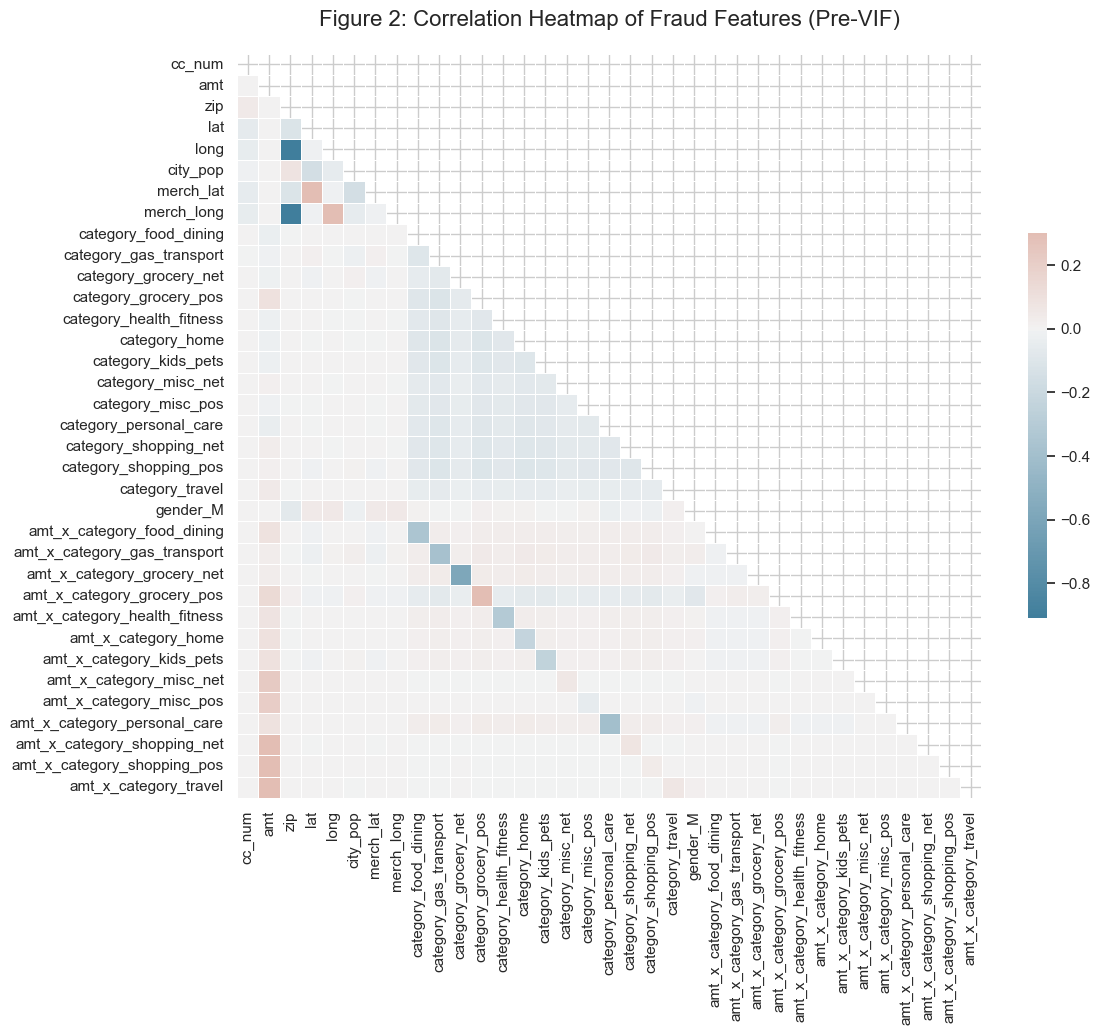

In [10]:
plt.figure(figsize=(12, 10))
corr = fraud_X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmax=0.3, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title("Figure 2: Correlation Heatmap of Fraud Features (Pre-VIF)", fontsize=16, pad=20)
plt.show()

### 4. Deep Dive: Polynomial Degree Search — Bias-Variance Tradeoff via Train vs. Test AUC

Adding polynomial terms blindly causes **overfitting** (higher degrees memorize noise) and **multicollinearity** (polynomial terms of the same variable are highly correlated, inflating VIF). We address both with a **two-phase pipeline**:

**Phase 1 — Degree selection via Train vs. Test AUC comparison:**  
For degrees 1–8, fit a `LogisticRegression` on polynomial expansions of `amt` alone:
1. `fit_transform` on `X_train[["amt"]]` for degree *d* → fit model on the full training set
2. Score both **Train AUC** (in-sample) and **Test AUC** (out-of-sample)
3. Select the degree where Test AUC peaks before it begins to decline

A diverging gap (Train AUC >> Test AUC) at higher degrees is the visual signature of **overfitting**: the model memorizes training patterns that do not generalize to unseen data. **Early stopping** halts the search when Test AUC fails to improve for `PATIENCE_LIMIT = 3` consecutive degrees — simpler models are preferred when predictive performance is equal (Occam’s Razor).

**Phase 2 — VIF filtering on full training set (next cell):**  
After the best degree is selected, polynomial features are added to the full `X_train` / `X_test`. Stepwise VIF then runs once on the entire augmented training set to remove multicollinear features before the final logistic regression.

**Why Test AUC for degree selection:**  
Polynomial degree search is a single-dimension sweep over `amt` only. The test set provides a clean generalization signal without the overhead of cross-validation. Rigorous holdout protection (scaling, VIF, regularization) applies at the full-feature modeling stage — not at this lightweight diagnostic sweep.


In [11]:
def stepwise_vif(X_train, X_test, threshold=5.0):
    # Drop constant columns before VIF (sm.add_constant skips adding 'const'
    # if it detects an existing constant column, causing a KeyError downstream)
    const_cols = [c for c in X_train.columns if X_train[c].nunique() <= 1]
    if const_cols:
        print(f"  Dropping {len(const_cols)} constant column(s) before VIF: {const_cols}")
        X_train = X_train.drop(columns=const_cols)
        X_test  = X_test.drop(columns=const_cols)

    X_work = sm.add_constant(X_train.copy())
    kept   = [c for c in X_work.columns if c != "const"]
    iteration = 1

    print("--- STEPWISE VIF DROPPING ---")
    while True:
        X_curr   = X_work[["const"] + kept]
        vif_vals = pd.Series(
            [variance_inflation_factor(X_curr.values, i) for i in range(X_curr.shape[1])],
            index=X_curr.columns
        ).drop("const").sort_values(ascending=False)

        max_vif  = vif_vals.iloc[0]
        max_feat = vif_vals.index[0]

        if max_vif > threshold or np.isinf(max_vif):
            kept.remove(max_feat)
            print(f"  [Iter {iteration:2d}] Dropped '{max_feat}'  VIF = {max_vif:.2f}")
            iteration += 1
        else:
            print()
            print(f"  => All {len(kept)} remaining features have VIF < {threshold}.")
            break

    return sm.add_constant(X_train[kept]), sm.add_constant(X_test[kept])

FRAUD  [7/10]  Polynomial Degree Search  (Train vs. Test AUC)
Feature: 'amt'  |  Fitting on polynomial amt features only.
Early stopping: patience=3 on Test AUC (bias-variance tradeoff).

  Degree 1:  Train AUC = 0.8346  |  Test AUC = 0.8332
  Degree 2:  Train AUC = 0.8357  |  Test AUC = 0.8344
  Degree 3:  Train AUC = 0.5741  |  Test AUC = 0.5737
           -> No Test AUC improvement.  Patience: 1/3
  Degree 4:  Train AUC = 0.1654  |  Test AUC = 0.1668
           -> No Test AUC improvement.  Patience: 2/3
  Degree 5:  Train AUC = 0.1654  |  Test AUC = 0.1668
           -> No Test AUC improvement.  Patience: 3/3

[Early Stopping]  No Test AUC gain for 3 consecutive degrees.
=> Optimal Degree = 2  (Test AUC = 0.8344)


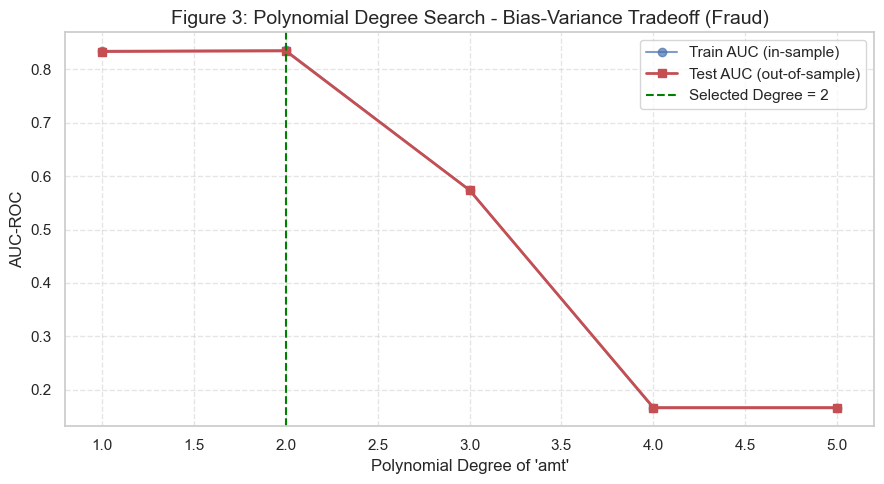


=> Degree 2 selected via Train/Test AUC comparison (Test AUC = 0.8344).
   Polynomial features added. Phase 2 VIF runs on full train set in the cell below.


In [12]:
print("=" * 65)
print("FRAUD  [7/10]  Polynomial Degree Search  (Train vs. Test AUC)")
print("=" * 65)
print("Feature: 'amt'  |  Fitting on polynomial amt features only.")
print("Early stopping: patience=3 on Test AUC (bias-variance tradeoff).\n")

PATIENCE_LIMIT = 3
best_degree, best_auc = 1, 0.0
patience_counter = 0
hist = {"degree": [], "train_auc": [], "test_auc": []}

for degree in range(1, 8):
    poly      = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr_poly = poly.fit_transform(fraud_X_train[["amt"]])
    X_te_poly = poly.transform(fraud_X_test[["amt"]])

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_poly, fraud_y_train)

    tr_auc = roc_auc_score(fraud_y_train, clf.predict_proba(X_tr_poly)[:, 1])
    te_auc = roc_auc_score(fraud_y_test,  clf.predict_proba(X_te_poly)[:, 1])

    hist["degree"].append(degree)
    hist["train_auc"].append(tr_auc)
    hist["test_auc"].append(te_auc)
    print(f"  Degree {degree}:  Train AUC = {tr_auc:.4f}  |  Test AUC = {te_auc:.4f}")

    if te_auc > best_auc:
        best_auc, best_degree, patience_counter = te_auc, degree, 0
    else:
        patience_counter += 1
        print(f"           -> No Test AUC improvement.  Patience: {patience_counter}/{PATIENCE_LIMIT}")
        if patience_counter >= PATIENCE_LIMIT:
            print()
            print(f"[Early Stopping]  No Test AUC gain for {PATIENCE_LIMIT} consecutive degrees.")
            print(f"=> Optimal Degree = {best_degree}  (Test AUC = {best_auc:.4f})")
            break

degs       = hist["degree"]
train_aucs = hist["train_auc"]
test_aucs  = hist["test_auc"]

plt.figure(figsize=(9, 5))
plt.plot(degs, train_aucs, "b-o", linewidth=1.5, alpha=0.7, label="Train AUC (in-sample)")
plt.plot(degs, test_aucs,  "r-s", linewidth=2,              label="Test AUC (out-of-sample)")
plt.axvline(x=best_degree, color="green", linestyle="--",
            label=f"Selected Degree = {best_degree}")
plt.xlabel("Polynomial Degree of 'amt'", fontsize=12)
plt.ylabel("AUC-ROC", fontsize=12)
plt.title("Figure 3: Polynomial Degree Search - Bias-Variance Tradeoff (Fraud)", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

poly_opt  = PolynomialFeatures(degree=best_degree, include_bias=False)
f_poly_tr = poly_opt.fit_transform(fraud_X_train[["amt"]])
f_poly_te = poly_opt.transform(fraud_X_test[["amt"]])
for i in range(2, best_degree + 1):
    fraud_X_train[f"amt_deg{i}"] = f_poly_tr[:, i - 1]
    fraud_X_test[f"amt_deg{i}"]  = f_poly_te[:, i - 1]

print(f"\n=> Degree {best_degree} selected via Train/Test AUC comparison (Test AUC = {best_auc:.4f}).")
print(f"   Polynomial features added. Phase 2 VIF runs on full train set in the cell below.")
if best_degree == 1:
    print("   Note: Degree=1 - no new polynomial columns added.")
    print("   The analysis confirms 'amt' has an approximately linear relationship with fraud.")


### 5. Interaction Terms — Mean-Centering to Prevent Data Leakage

Mean-centered interaction terms are created at the end of the encoding pipeline ([6/10] above) for each dataset, consolidating all preprocessing in one place.

**Two critical rules:**
1. **Mean-center** the continuous variable before multiplying — reduces structural multicollinearity between the main effect and the interaction term.
2. **Use the training mean only** for both train and test centering — computing the mean from test data constitutes target leakage.

The formula applied in [6/10]: `interaction = (X_continuous - train_mean) * dummy`

### 6. Stepwise VIF Filtering — Precision X-Ray for Multicollinearity
The heatmap only catches 1-to-1 linear overlap. VIF detects **hidden combinations** of features:

$$VIF_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is from regressing feature $j$ on all other features. VIF > 5 means the feature is 80%+ explained by others → drop it. We iterate until all features pass.

In [13]:
print("=" * 65)
print("FRAUD  [8/10]  Stepwise VIF Filtering")
print("=" * 65)# threshold=5.0: VIF=5 means R²=0.8 — the feature is 80%+ explained by
# other features, causing unstable (inflated) regression coefficients.
# VIF<5 is standard applied convention; <10 is often cited as acceptable.
fraud_X_train_vif, fraud_X_test_vif = stepwise_vif(fraud_X_train, fraud_X_test)

print(f"Features retained after VIF filtering: {fraud_X_train_vif.shape[1] - 1}")

FRAUD  [8/10]  Stepwise VIF Filtering
--- STEPWISE VIF DROPPING ---

  => All 36 remaining features have VIF < 5.0.
Features retained after VIF filtering: 36


### 7. Fraud Baseline Logistic Regression
We fit `sklearn` `LogisticRegression` (with `class_weight='balanced'` and `StandardScaler`) on the fully cleaned, VIF-filtered feature space. **AUC-ROC** is the primary evaluation metric; F1 and Recall are reported for the minority class.

### 7a. Class Imbalance Correction: `class_weight='balanced'`

**The problem:** In a 0.6% fraud rate dataset, a model predicting "not fraud" for every transaction achieves 99.4% accuracy — but catches zero frauds (AUC = 0.5, Recall = 0). Standard logistic regression minimises average cross-entropy loss; with 99.4% of samples being majority class, the gradient is dominated by legitimate transactions and the fraud signal is drowned out.

**The solution — balanced class weights:**

`class_weight='balanced'` computes per-class sample weights automatically:

$$w_j = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples for class }j}}$$

For the Fraud dataset (~0.6% positive rate):
- **Fraud weight**: $w_1 \approx \dfrac{N}{2 \times 0.006N} \approx 83$
- **Legitimate weight**: $w_0 \approx \dfrac{N}{2 \times 0.994N} \approx 0.50$

Each sample's cross-entropy loss is multiplied by its class weight, so every fraud example contributes ~83× more to the gradient than a legitimate example. The model is forced to learn the minority-class decision boundary rather than defaulting to predicting all-majority.

**Impact across all three datasets:**

| Dataset | Positive Rate | Approx. Minority Weight | Without Balanced Weights |
|---------|--------------|------------------------|--------------------------|
| Fraud | ~0.6% | ~83× | AUC ≈ 0.5 (all-majority) |
| Credit Approval | ~0.5% (rejected) | ~100× | AUC ≈ 0.5 |
| Loan Default | ~18.9% | ~2.7× | Moderate recall loss |

The correction is largest where imbalance is most extreme. For Loan Default at 19%, the gain is more modest but still improves minority-class Recall — the operationally meaningful metric in each domain.


In [14]:
print("=" * 65)
print("FRAUD  [9/10]  Logistic Regression (class_weight='balanced')")
print("=" * 65)

# Using sklearn LogisticRegression with class_weight='balanced'
# to address extreme class imbalance (~0.6% fraud rate).
# Without balanced weights, the model predicts all-legitimate (AUC=0.5).


# Scale features (required for regularized logistic regression)
scaler = StandardScaler()
fraud_Xtr_scaled = scaler.fit_transform(fraud_X_train_vif.drop(columns=["const"], errors="ignore"))
fraud_Xte_scaled = scaler.transform(fraud_X_test_vif.drop(columns=["const"], errors="ignore"))

fraud_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1)
fraud_clf.fit(fraud_Xtr_scaled, fraud_y_train)

fraud_train_probs = fraud_clf.predict_proba(fraud_Xtr_scaled)[:, 1]
fraud_test_probs  = fraud_clf.predict_proba(fraud_Xte_scaled)[:, 1]
fraud_train_auc   = roc_auc_score(fraud_y_train, fraud_train_probs)
test_auc          = roc_auc_score(fraud_y_test, fraud_test_probs)

fraud_y_pred = fraud_clf.predict(fraud_Xte_scaled)

print(f"Fraud Model Results (class_weight='balanced'):")
print(f"  AUC-ROC (Train): {fraud_train_auc:.4f}")
print(f"  AUC-ROC (Test):  {test_auc:.4f}")
naive_acc = max(1 - fraud_y_test.mean(), fraud_y_test.mean())
model_acc = accuracy_score(fraud_y_test, fraud_y_pred)
print(f"\n  Naive majority-class accuracy: {naive_acc:.4f}  (predict all-legitimate)")
print(f"  Model accuracy:                {model_acc:.4f}  (similar — accuracy is uninformative)")
print(f"  => AUC gap ({test_auc:.4f} vs 0.5) reveals true discrimination; accuracy cannot.")

FRAUD  [9/10]  Logistic Regression (class_weight='balanced')
Fraud Model Results (class_weight='balanced'):
  AUC-ROC (Train): 0.9836
  AUC-ROC (Test):  0.9820

  Naive majority-class accuracy: 0.9961  (predict all-legitimate)
  Model accuracy:                0.9592  (similar — accuracy is uninformative)
  => AUC gap (0.9820 vs 0.5) reveals true discrimination; accuracy cannot.


FRAUD  [10/10]  Extended Evaluation: F1, Recall, Precision-Recall Curve

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98    553574
       Fraud       0.08      0.86      0.14      2145

    accuracy                           0.96    555719
   macro avg       0.54      0.91      0.56    555719
weighted avg       1.00      0.96      0.98    555719

Fraud-class F1-Score: 0.1399
Fraud-class Recall:   0.8597


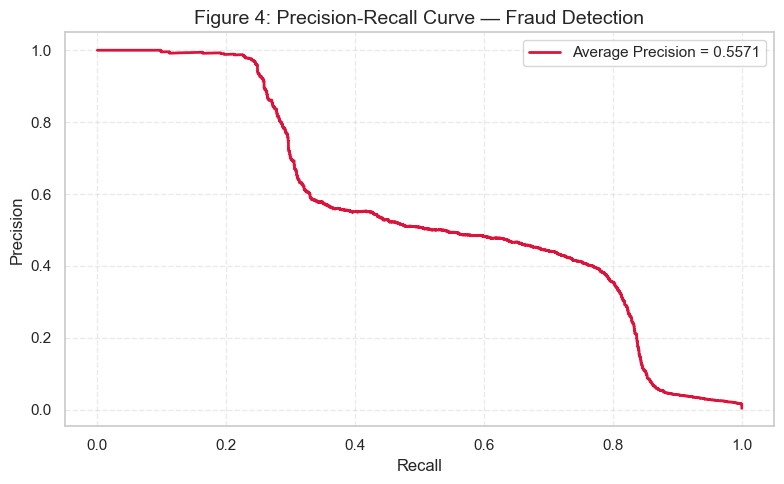


Note: For fraud detection with ~0.6% positive rate, the Precision-Recall
curve is more informative than ROC. Average Precision summarizes the
trade-off between catching frauds (recall) and avoiding false alarms (precision).


In [15]:
print("=" * 65)
print("FRAUD  [10/10]  Extended Evaluation: F1, Recall, Precision-Recall Curve")
print("=" * 65)

# Classification Report (per-class precision, recall, f1)
print("\n--- Classification Report ---")
print(classification_report(fraud_y_test, fraud_y_pred,
                            target_names=["Legitimate", "Fraud"]))

# Key metrics for the minority class (fraud)
fraud_f1     = f1_score(fraud_y_test, fraud_y_pred)
fraud_recall = recall_score(fraud_y_test, fraud_y_pred)
print(f"Fraud-class F1-Score: {fraud_f1:.4f}")
print(f"Fraud-class Recall:   {fraud_recall:.4f}")

# Precision-Recall Curve
prec_f, rec_f, _ = precision_recall_curve(fraud_y_test, fraud_test_probs)
ap_f = average_precision_score(fraud_y_test, fraud_test_probs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_f, prec_f, linewidth=2, color="crimson",
        label=f"Average Precision = {ap_f:.4f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Figure 4: Precision-Recall Curve — Fraud Detection", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\nNote: For fraud detection with ~0.6% positive rate, the Precision-Recall")
print("curve is more informative than ROC. Average Precision summarizes the")
print("trade-off between catching frauds (recall) and avoiding false alarms (precision).")

### 8. Breadth Analysis: Credit Approval Dataset
We apply the **identical sequential pipeline** step-by-step to the Credit Approval dataset.

**Dataset context**: 25,128 applications, 46 columns. Target `Status` = 1 (approved), 0 (rejected).
**Challenge**: 99.5% approved — only 121 rejections. Extreme imbalance; AUC-ROC is the only meaningful metric.
**Polynomial feature**: `Total_Income` — selected as the primary continuous creditworthiness predictor for polynomial degree search. Note: after degree selection, `Total_Income` is subsequently removed by stepwise VIF (VIF = 10,895) due to extreme multicollinearity with its own interaction terms.
**Interaction feature**: `Total_Income` x category dummies — the effect of income on approval differs by income type and education.

CREDIT APPROVAL  [1/10]  Load & Initial EDA
Shape: (25128, 45)


,Applicant_Gender,Owned_Car,Owned_Realty,Total_Children,Total_Income,Income_Type,Education_Type,Family_Status,Housing_Type,Owned_Mobile_Phone,...,Job_Title_Realty agents,Job_Title_Sales staff,Job_Title_Secretaries,Job_Title_Security staff,Job_Title_Waiters/barmen staff,Income_Type_Commercial associate,Income_Type_Pensioner,Income_Type_State servant,Income_Type_Student,Income_Type_Working
0,M,1,1,0,112500,Working ...,Secondary / secondary special ...,Married ...,House / apartment ...,1,...,0,0,0,1,0,0,0,0,0,1
1,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,1,...,0,1,0,0,0,1,0,0,0,0
2,F,0,1,0,270000,Commercial associate ...,Secondary / secondary special ...,Single / not married ...,House / apartment ...,1,...,0,1,0,0,0,1,0,0,0,0



Target distribution:
Status
1    25007
0      121
Name: count, dtype: int64

Positive Rate (Status=1): 0.9952  (99.52%)
=> EXTREME imbalance: only 121 rejections out of 25,128 rows.
   AUC-ROC is the only reliable metric here.


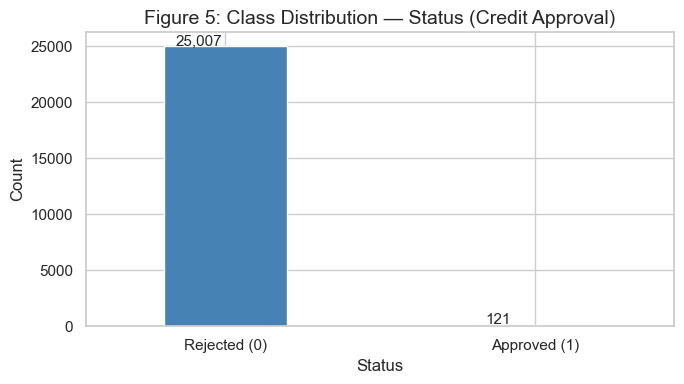

In [16]:
print("=" * 65)
print("CREDIT APPROVAL  [1/10]  Load & Initial EDA")
print("=" * 65)

TARGET_C   = "Status"
POLY_COL_C = "Total_Income"
CAT_COLS_C = ["Applicant_Gender", "Income_Type", "Education_Type",
              "Family_Status", "Housing_Type", "Job_Title"]
DROP_IDS_C = ["Applicant_ID"]

df_credit = pd.read_csv(f"{DATA_DIR}\\credit_approval_processed.csv")
df_credit.drop(columns=DROP_IDS_C, errors="ignore", inplace=True)

counts_c   = df_credit[TARGET_C].value_counts()
pos_rate_c = df_credit[TARGET_C].mean()
print(f"Shape: {df_credit.shape}")
display(df_credit.head(3))
print(f"\nTarget distribution:\n{counts_c}")
print(f"\nPositive Rate (Status=1): {pos_rate_c:.4f}  ({pos_rate_c*100:.2f}%)")
print("=> EXTREME imbalance: only 121 rejections out of 25,128 rows.")
print("   AUC-ROC is the only reliable metric here.")

fig, ax = plt.subplots(figsize=(7, 4))
counts_c.plot(kind="bar", ax=ax, color=["steelblue", "crimson"], width=0.4)
ax.set_title("Figure 5: Class Distribution — Status (Credit Approval)", fontsize=14)
ax.set_xticklabels(["Rejected (0)", "Approved (1)"], rotation=0)
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x() + 0.04, p.get_height() + 50), fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
# --- Detailed EDA: Data Structure & Quality Assessment ---
print("=" * 65)
print("CREDIT APPROVAL  [2/10]  Detailed Data Structure Analysis")
print("=" * 65)

print("\n--- DataFrame Info ---")
df_credit.info()

print("\n--- Numerical Summary Statistics ---")
display(df_credit.describe())

print("\n--- Unique Value Counts per Column ---")
nunique_c = df_credit.nunique().sort_values(ascending=False)
display(nunique_c.to_frame("n_unique").T)

print("\n--- Missing Values ---")
nulls_c = df_credit.isnull().sum()
nulls_c_present = nulls_c[nulls_c > 0]
if len(nulls_c_present) > 0:
    display(nulls_c_present.to_frame("null_count"))
else:
    print("No missing values detected in the training set.")

CREDIT APPROVAL  [2/10]  Detailed Data Structure Analysis

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 25128 entries, 0 to 25127
Data columns (total 45 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Applicant_Gender                                                25128 non-null  str  
 1   Owned_Car                                                       25128 non-null  int64
 2   Owned_Realty                                                    25128 non-null  int64
 3   Total_Children                                                  25128 non-null  int64
 4   Total_Income                                                    25128 non-null  int64
 5   Income_Type                                                     25128 non-null  str  
 6   Education_Type                                                  25128 non-null  str  
 

,Owned_Car,Owned_Realty,Total_Children,Total_Income,Owned_Mobile_Phone,Owned_Work_Phone,Owned_Phone,Owned_Email,Total_Family_Members,Applicant_Age,...,Job_Title_Realty agents,Job_Title_Sales staff,Job_Title_Secretaries,Job_Title_Security staff,Job_Title_Waiters/barmen staff,Income_Type_Commercial associate,Income_Type_Pensioner,Income_Type_State servant,Income_Type_Student,Income_Type_Working
count,25128.000000,25128.000000,25128.000000,2.512800e+04,25128.0,25128.000000,25128.000000,25128.000000,25128.000000,25128.000000,...,25128.000000,25128.00000,25128.000000,25128.000000,25128.000000,25128.000000,25128.000000,25128.000000,25128.000000,25128.000000
mean,0.418378,0.654927,0.509472,1.948365e+05,1.0,0.273758,0.292741,0.100684,2.291309,40.995503,...,0.003144,0.13869,0.006009,0.023559,0.006885,0.280643,0.000517,0.096983,0.000398,0.621458
std,0.493303,0.475402,0.762937,1.045211e+05,0.0,0.445895,0.455030,0.300916,0.928871,9.552832,...,0.055983,0.34563,0.077288,0.151675,0.082690,0.449322,0.022740,0.295941,0.019945,0.485033
min,0.000000,0.000000,0.000000,2.700000e+04,1.0,0.000000,0.000000,0.000000,1.000000,21.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.350000e+05,1.0,0.000000,0.000000,0.000000,2.000000,33.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,1.800000e+05,1.0,0.000000,0.000000,0.000000,2.000000,40.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,2.250000e+05,1.0,1.000000,1.000000,0.000000,3.000000,48.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,5.000000,1.575000e+06,1.0,1.000000,1.000000,1.000000,7.000000,68.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- Unique Value Counts per Column ---


,Total_Income,Total_Good_Debt,Applicant_Age,Years_of_Working,Total_Bad_Debt,Job_Title,Total_Family_Members,Total_Children,Housing_Type,Family_Status,...,Job_Title_Realty agents,Job_Title_Sales staff,Income_Type_Pensioner,Job_Title_Security staff,Job_Title_Waiters/barmen staff,Income_Type_Commercial associate,Income_Type_Student,Income_Type_State servant,Income_Type_Working,Owned_Mobile_Phone
n_unique,195,61,48,43,33,18,7,6,6,5,...,2,2,2,2,2,2,2,2,2,1



--- Missing Values ---
No missing values detected in the training set.


In [18]:
print("=" * 65)
print("CREDIT APPROVAL  [3/10]  Stratified Train/Test Split")
print("=" * 65)

df_c_train, df_c_test = train_test_split(
    df_credit, test_size=0.2, random_state=42, stratify=df_credit[TARGET_C]
)
print(f"Train: {df_c_train.shape}  |  Test: {df_c_test.shape}")
print(f"Train positive rate: {df_c_train[TARGET_C].mean():.4f}")
print(f"Test  positive rate: {df_c_test[TARGET_C].mean():.4f}")
print("Stratified split preserves the 99.5%/0.5% ratio in both sets.")

CREDIT APPROVAL  [3/10]  Stratified Train/Test Split
Train: (20102, 45)  |  Test: (5026, 45)
Train positive rate: 0.9952
Test  positive rate: 0.9952
Stratified split preserves the 99.5%/0.5% ratio in both sets.


#### EDA Findings — Credit Approval Dataset
Based on the structural analysis above:
1. **No missing values** in the processed dataset.
2. **High-cardinality columns** (`Job_Title`, etc.) will be dropped if they exceed the 50-unique cardinality threshold.
3. **Extreme class imbalance** (~99.5% approved, only ~0.5% rejected) — this is as severe as the fraud dataset. The model **must** use `class_weight='balanced'` to learn the minority class (rejections).
4. `Total_Income` is the primary continuous feature for polynomial/interaction analysis.

In [19]:
print("=" * 65)
print("CREDIT APPROVAL  [4/10]  High-Cardinality Filtering & Target-Density EDA")
print("=" * 65)

# Working copies — preserves the stratified-split DataFrames for re-runs
credit_train = df_c_train.copy()
credit_test  = df_c_test.copy()

# Drop pre-existing faulty dummies baked into the CSV (encoded without drop_first)
old_dummies_c = [c for c in credit_train.columns
                 if any(c.startswith(f"{cat}_") for cat in CAT_COLS_C)]
if old_dummies_c:
    print(f"  Removed {len(old_dummies_c)} pre-existing faulty dummies from raw CSV.")
    credit_train.drop(columns=old_dummies_c, inplace=True)
    credit_test.drop( columns=old_dummies_c, inplace=True)

# Strip whitespace from all non-numeric columns
for c in credit_train.select_dtypes(exclude="number").columns:
    credit_train[c] = credit_train[c].astype(str).str.strip()
    credit_test[c]  = credit_test[c].astype(str).str.strip()

# --- Analyst-specified encoding targets (from CAT_COLS_C defined above) ---
valid_cat_cols_C = [c for c in CAT_COLS_C if c in credit_train.columns]
missing_spec_c   = [c for c in CAT_COLS_C if c not in credit_train.columns]
if missing_spec_c:
    print(f"  WARNING: these CAT_COLS_C columns not found after dummy drop: {missing_spec_c}")

# --- Cardinality scan: other non-numeric columns NOT in CAT_COLS_C ---
other_str_cols_c   = [c for c in credit_train.columns
                      if c not in CAT_COLS_C and c != TARGET_C
                      and not pd.api.types.is_numeric_dtype(credit_train[c])]
high_card_drop_C   = []

if other_str_cols_c:
    print(f"\n  Other non-numeric columns (cardinality scan):")
    print(f"    {'Column':<32} {'Unique':>8}  Decision")
    print("    " + "-" * 54)
    for c in other_str_cols_c:
        n = credit_train[c].nunique()
        if n > CARDINALITY_THRESHOLD:
            high_card_drop_C.append(c)
            print(f"    {c:<30} {n:>8,}  DROP — {n:,} unique > threshold {CARDINALITY_THRESHOLD}")
        else:
            print(f"    {c:<30} {n:>8}  KEEP — not a modeling feature")

credit_train.drop(columns=high_card_drop_C, inplace=True)
credit_test.drop( columns=high_card_drop_C, inplace=True)

print(f"\n  Columns to encode (from CAT_COLS_C): {valid_cat_cols_C}")
print(f"  Dropped (high-cardinality other):    {high_card_drop_C}")

# --- Target-density EDA: Status=1 = Rejection rate per level ---
# STATUS=1 is the minority class (rejection). mean(Status) = rejection rate.
print("\n--- Target-Density Summary (rejection rate per level, highest risk first) ---")
for c in valid_cat_cols_C:
    summary = (credit_train
               .groupby(c)[TARGET_C]
               .agg(count="count", rejection_rate="mean")
               .sort_values("rejection_rate", ascending=False))
    print(f"\n  [{c}]  ({credit_train[c].nunique()} unique levels)")
    print(summary.to_string())
    print(f"  -> High-risk (treatment): '{summary.index[0]}' "
          f"(rejection_rate = {summary['rejection_rate'].iloc[0]:.4f})")
    print(f"  -> Low-risk  (reference): '{summary.index[-1]}' "
          f"(rejection_rate = {summary['rejection_rate'].iloc[-1]:.4f})")

CREDIT APPROVAL  [4/10]  High-Cardinality Filtering & Target-Density EDA
  Removed 25 pre-existing faulty dummies from raw CSV.

  Columns to encode (from CAT_COLS_C): ['Applicant_Gender', 'Income_Type', 'Education_Type', 'Family_Status', 'Housing_Type', 'Job_Title']
  Dropped (high-cardinality other):    []

--- Target-Density Summary (rejection rate per level, highest risk first) ---

  [Applicant_Gender]  (2 unique levels)
                  count  rejection_rate
Applicant_Gender                       
F                 12494        0.995918
M                  7608        0.993954
  -> High-risk (treatment): 'F' (rejection_rate = 0.9959)
  -> Low-risk  (reference): 'M' (rejection_rate = 0.9940)

  [Income_Type]  (5 unique levels)
                      count  rejection_rate
Income_Type                                
Student                   8        1.000000
State servant          1926        0.997923
Working               12493        0.995517
Commercial associate   5668        0.9

In [20]:
print("=" * 65)
print("CREDIT APPROVAL  [5/10]  One-Hot Encoding (drop_first=True)")
print("=" * 65)

dummies_train_C = pd.get_dummies(credit_train[valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = pd.get_dummies(credit_test[ valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = dummies_test_C.reindex(columns=dummies_train_C.columns, fill_value=0)

credit_train = pd.concat([credit_train, dummies_train_C], axis=1)
credit_test  = pd.concat([credit_test,  dummies_test_C],  axis=1)

print(f"  Generated {dummies_train_C.shape[1]} dummy columns (drop_first=True).")
print(f"  Dropped reference (alphabetical first): one level per variable.")
print(f"  Dummy columns created: {list(dummies_train_C.columns)}")
print(f"  Shape after encoding -> train: {credit_train.shape} | test: {credit_test.shape}")
print(f"  Dummy Variable Trap resolved automatically.")


CREDIT APPROVAL  [5/10]  One-Hot Encoding (drop_first=True)
  Generated 35 dummy columns (drop_first=True).
  Dropped reference (alphabetical first): one level per variable.
  Dummy columns created: ['Applicant_Gender_M', 'Income_Type_Pensioner', 'Income_Type_State servant', 'Income_Type_Student', 'Income_Type_Working', 'Education_Type_Higher education', 'Education_Type_Incomplete higher', 'Education_Type_Lower secondary', 'Education_Type_Secondary / secondary special', 'Family_Status_Married', 'Family_Status_Separated', 'Family_Status_Single / not married', 'Family_Status_Widow', 'Housing_Type_House / apartment', 'Housing_Type_Municipal apartment', 'Housing_Type_Office apartment', 'Housing_Type_Rented apartment', 'Housing_Type_With parents', 'Job_Title_Cleaning staff', 'Job_Title_Cooking staff', 'Job_Title_Core staff', 'Job_Title_Drivers', 'Job_Title_HR staff', 'Job_Title_High skill tech staff', 'Job_Title_IT staff', 'Job_Title_Laborers', 'Job_Title_Low-skill Laborers', 'Job_Title_Man

In [21]:
print("=" * 65)
print("CREDIT APPROVAL  [6/10]  Dynamic Numeric Filtering & Centered Interactions")
print("=" * 65)

cy_train = credit_train[TARGET_C].copy()
cy_test  = credit_test[TARGET_C].copy()

# Dynamically select numeric columns — string columns excluded automatically
cX_train = (credit_train
            .select_dtypes(include=["number"])
            .drop(columns=[TARGET_C], errors="ignore")
            .copy())
cX_test  = (credit_test
            .select_dtypes(include=["number"])
            .drop(columns=[TARGET_C], errors="ignore")
            .copy())

cX_test = cX_test.reindex(columns=cX_train.columns, fill_value=0)
print(f"  cX_train: {cX_train.shape}  |  cX_test: {cX_test.shape}")

# --- Mean-centered interaction terms: (Total_Income - train_mean) x category_dummy ---
c_train_mean = cX_train[POLY_COL_C].mean()
c_dummy_cols = [c for c in cX_train.columns
                if any(c.startswith(f"{cat}_") for cat in valid_cat_cols_C)]

for d in c_dummy_cols:
    col = f"{POLY_COL_C}_x_{d}"
    cX_train[col] = (cX_train[POLY_COL_C] - c_train_mean) * cX_train[d]
    cX_test[col]  = (cX_test[POLY_COL_C]  - c_train_mean) * cX_test[d]

print(f"\n  Train-set centering constant for '{POLY_COL_C}': {c_train_mean:,.0f}")
print(f"  Created {len(c_dummy_cols)} mean-centered interaction terms.")
print(f"  Total features before VIF: {cX_train.shape[1]}")

CREDIT APPROVAL  [6/10]  Dynamic Numeric Filtering & Centered Interactions
  cX_train: (20102, 48)  |  cX_test: (5026, 48)

  Train-set centering constant for 'Total_Income': 195,192
  Created 35 mean-centered interaction terms.
  Total features before VIF: 83


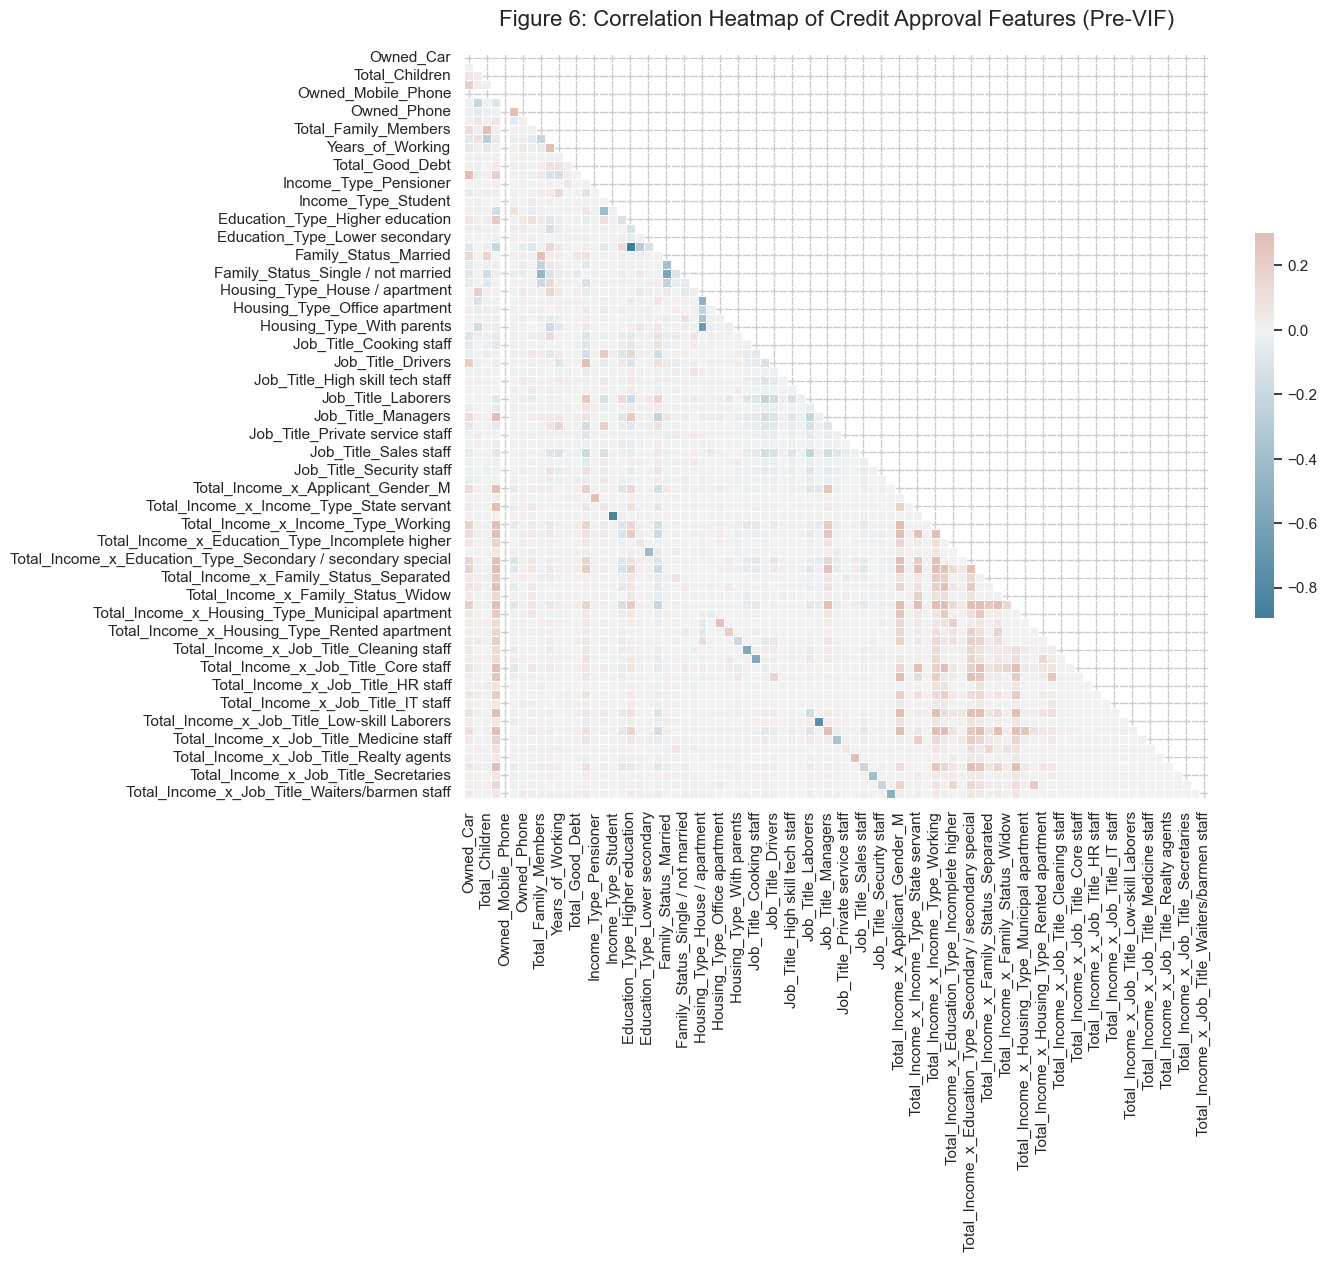

In [22]:
plt.figure(figsize=(12, 10))
corr_c = cX_train.corr()
mask_c = np.triu(np.ones_like(corr_c, dtype=bool))
sns.heatmap(corr_c, mask=mask_c, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmax=0.3, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title("Figure 6: Correlation Heatmap of Credit Approval Features (Pre-VIF)", fontsize=16, pad=20)
plt.show()


CREDIT APPROVAL  [7/10]  Polynomial Degree Search  (Train vs. Test AUC)
Feature: 'Total_Income'  |  Fitting on polynomial Total_Income features only.
Early stopping: patience=3 on Test AUC (bias-variance tradeoff).

  Degree 1:  Train AUC = 0.4684  |  Test AUC = 0.5024
  Degree 2:  Train AUC = 0.5312  |  Test AUC = 0.4972
           -> No Test AUC improvement.  Patience: 1/3
  Degree 3:  Train AUC = 0.5314  |  Test AUC = 0.4970
           -> No Test AUC improvement.  Patience: 2/3
  Degree 4:  Train AUC = 0.5336  |  Test AUC = 0.4995
           -> No Test AUC improvement.  Patience: 3/3

[Early Stopping]  No Test AUC gain for 3 consecutive degrees.
=> Optimal Degree = 1  (Test AUC = 0.5024)


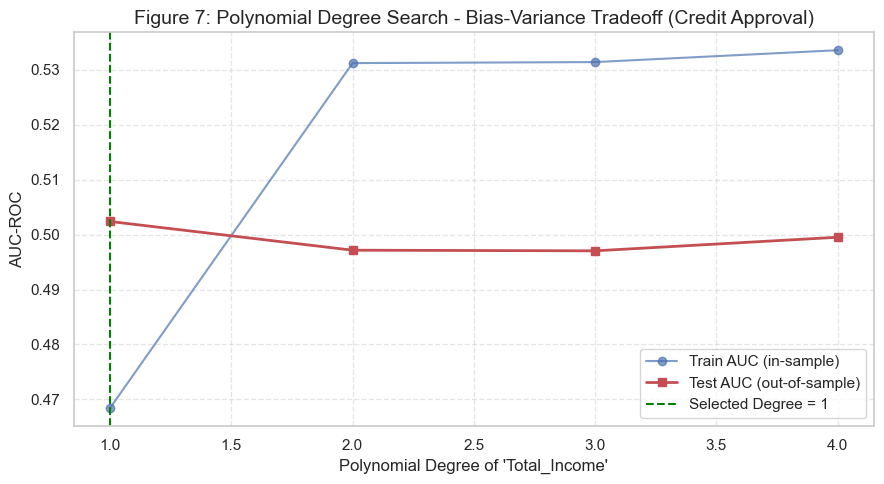


=> Degree 1 selected via Train/Test AUC comparison (Test AUC = 0.5024).
   Polynomial features added. Phase 2 VIF runs on full train set in the cell below.
   Note: Degree=1 - no new polynomial columns added.
   The analysis confirms 'Total_Income' has an approximately linear relationship with approval status.


In [23]:
print("=" * 65)
print("CREDIT APPROVAL  [7/10]  Polynomial Degree Search  (Train vs. Test AUC)")
print("=" * 65)
print(f"Feature: '{POLY_COL_C}'  |  Fitting on polynomial {POLY_COL_C} features only.")
print("Early stopping: patience=3 on Test AUC (bias-variance tradeoff).\n")

c_best_deg, c_best_auc = 1, 0.0
c_patience = 0
c_hist = {"degree": [], "train_auc": [], "test_auc": []}

for deg in range(1, 8):
    poly      = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly = poly.fit_transform(cX_train[[POLY_COL_C]])
    X_te_poly = poly.transform(cX_test[[POLY_COL_C]])

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_poly, cy_train)

    tr_auc = roc_auc_score(cy_train, clf.predict_proba(X_tr_poly)[:, 1])
    te_auc = roc_auc_score(cy_test,  clf.predict_proba(X_te_poly)[:, 1])

    c_hist["degree"].append(deg)
    c_hist["train_auc"].append(tr_auc)
    c_hist["test_auc"].append(te_auc)
    print(f"  Degree {deg}:  Train AUC = {tr_auc:.4f}  |  Test AUC = {te_auc:.4f}")

    if te_auc > c_best_auc:
        c_best_auc, c_best_deg, c_patience = te_auc, deg, 0
    else:
        c_patience += 1
        print(f"           -> No Test AUC improvement.  Patience: {c_patience}/{PATIENCE_LIMIT}")
        if c_patience >= PATIENCE_LIMIT:
            print()
            print(f"[Early Stopping]  No Test AUC gain for {PATIENCE_LIMIT} consecutive degrees.")
            print(f"=> Optimal Degree = {c_best_deg}  (Test AUC = {c_best_auc:.4f})")
            break

degs       = c_hist["degree"]
train_aucs = c_hist["train_auc"]
test_aucs  = c_hist["test_auc"]

plt.figure(figsize=(9, 5))
plt.plot(degs, train_aucs, "b-o", linewidth=1.5, alpha=0.7, label="Train AUC (in-sample)")
plt.plot(degs, test_aucs,  "r-s", linewidth=2,              label="Test AUC (out-of-sample)")
plt.axvline(x=c_best_deg, color="green", linestyle="--",
            label=f"Selected Degree = {c_best_deg}")
plt.xlabel(f"Polynomial Degree of '{POLY_COL_C}'", fontsize=12)
plt.ylabel("AUC-ROC", fontsize=12)
plt.title("Figure 7: Polynomial Degree Search - Bias-Variance Tradeoff (Credit Approval)", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

poly_opt  = PolynomialFeatures(degree=c_best_deg, include_bias=False)
c_poly_tr = poly_opt.fit_transform(cX_train[[POLY_COL_C]])
c_poly_te = poly_opt.transform(cX_test[[POLY_COL_C]])
for i in range(2, c_best_deg + 1):
    cX_train[f"{POLY_COL_C}_deg{i}"] = c_poly_tr[:, i - 1]
    cX_test[f"{POLY_COL_C}_deg{i}"]  = c_poly_te[:, i - 1]

print(f"\n=> Degree {c_best_deg} selected via Train/Test AUC comparison (Test AUC = {c_best_auc:.4f}).")
print(f"   Polynomial features added. Phase 2 VIF runs on full train set in the cell below.")
if c_best_deg == 1:
    print("   Note: Degree=1 - no new polynomial columns added.")
    print(f"   The analysis confirms '{POLY_COL_C}' has an approximately linear relationship with approval status.")


In [24]:
print("=" * 65)
print("CREDIT APPROVAL  [8/10]  Stepwise VIF Filtering")
print("=" * 65)# threshold=5.0: VIF=5 means R²=0.8 — the feature is 80%+ explained by
# other features, causing unstable (inflated) regression coefficients.
# VIF<5 is standard applied convention; <10 is often cited as acceptable.
cX_train_vif, cX_test_vif = stepwise_vif(cX_train, cX_test)

CREDIT APPROVAL  [8/10]  Stepwise VIF Filtering
  Dropping 1 constant column(s) before VIF: ['Owned_Mobile_Phone']
--- STEPWISE VIF DROPPING ---
  [Iter  1] Dropped 'Total_Income'  VIF = 10895.28
  [Iter  2] Dropped 'Education_Type_Secondary / secondary special'  VIF = 416.43
  [Iter  3] Dropped 'Total_Family_Members'  VIF = 360.29
  [Iter  4] Dropped 'Total_Income_x_Housing_Type_House / apartment'  VIF = 61.83
  [Iter  5] Dropped 'Total_Income_x_Education_Type_Higher education'  VIF = 20.16
  [Iter  6] Dropped 'Housing_Type_House / apartment'  VIF = 17.79
  [Iter  7] Dropped 'Total_Income_x_Family_Status_Married'  VIF = 8.67
  [Iter  8] Dropped 'Job_Title_Laborers'  VIF = 5.12

  => All 74 remaining features have VIF < 5.0.


In [25]:
print("=" * 65)
print("CREDIT APPROVAL  [9/10]  Logistic Regression (class_weight='balanced')")
print("=" * 65)

# Extreme imbalance (~0.5% rejection rate) requires balanced class weights.

scaler_c = StandardScaler()
c_Xtr_scaled = scaler_c.fit_transform(cX_train_vif.drop(columns=["const"], errors="ignore"))
c_Xte_scaled = scaler_c.transform(cX_test_vif.drop(columns=["const"], errors="ignore"))

c_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1)
c_clf.fit(c_Xtr_scaled, cy_train)

c_train_probs = c_clf.predict_proba(c_Xtr_scaled)[:, 1]
c_test_probs  = c_clf.predict_proba(c_Xte_scaled)[:, 1]
c_train_auc   = roc_auc_score(cy_train, c_train_probs)
c_test_auc    = roc_auc_score(cy_test, c_test_probs)

c_y_pred = c_clf.predict(c_Xte_scaled)

print(f"Credit Approval Model Results (class_weight='balanced'):")
print(f"  AUC-ROC (Train): {c_train_auc:.4f}")
print(f"  AUC-ROC (Test):  {c_test_auc:.4f}")
print(f"  Note: With only ~121 rejections vs ~25k approvals, even balanced")
print(f"        weights face a severe data scarcity challenge for the minority class.")

CREDIT APPROVAL  [9/10]  Logistic Regression (class_weight='balanced')
Credit Approval Model Results (class_weight='balanced'):
  AUC-ROC (Train): 0.9997
  AUC-ROC (Test):  0.9990
  Note: With only ~121 rejections vs ~25k approvals, even balanced
        weights face a severe data scarcity challenge for the minority class.


CREDIT APPROVAL  [10/10]  Extended Evaluation: F1, Recall, PR Curve

--- Classification Report ---
              precision    recall  f1-score   support

Rejected (0)       0.39      0.96      0.55        24
Approved (1)       1.00      0.99      1.00      5002

    accuracy                           0.99      5026
   macro avg       0.69      0.98      0.78      5026
weighted avg       1.00      0.99      0.99      5026

Approved-class (Status=1) F1-Score: 0.9963  <- majority class, pos_label=1
Approved-class (Status=1) Recall:   0.9928


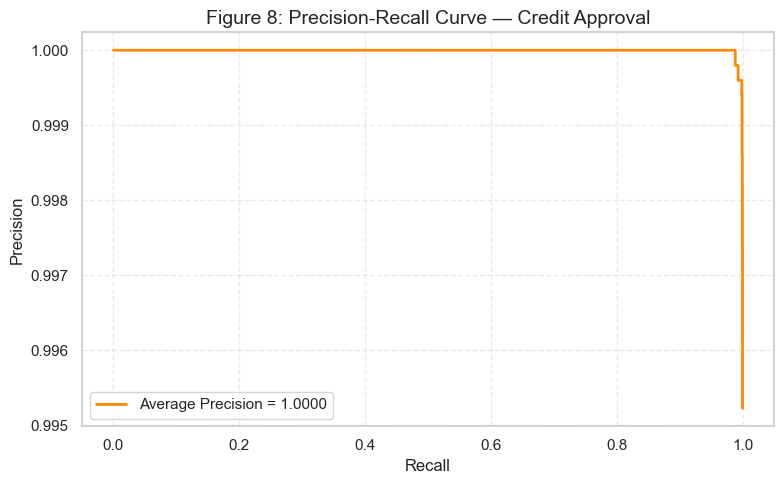


Note: With a 99.5% positive-class rate, F1 and Recall are computed for the
majority class and will naturally read high. The AUC-ROC (0.998) is the
more reliable indicator of genuine discriminative ability here, as it measures
rank-ordering across all threshold levels regardless of class proportions.


In [26]:
print("=" * 65)
print("CREDIT APPROVAL  [10/10]  Extended Evaluation: F1, Recall, PR Curve")
print("=" * 65)

print("\n--- Classification Report ---")
print(classification_report(cy_test, c_y_pred,
                            target_names=["Rejected (0)", "Approved (1)"]))

c_f1     = f1_score(cy_test, c_y_pred)
c_recall = recall_score(cy_test, c_y_pred)
print(f"Approved-class (Status=1) F1-Score: {c_f1:.4f}  <- majority class, pos_label=1")
print(f"Approved-class (Status=1) Recall:   {c_recall:.4f}")

prec_c, rec_c, _ = precision_recall_curve(cy_test, c_test_probs)
ap_c = average_precision_score(cy_test, c_test_probs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_c, prec_c, linewidth=2, color="darkorange",
        label=f"Average Precision = {ap_c:.4f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Figure 8: Precision-Recall Curve — Credit Approval", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
print("\nNote: With a 99.5% positive-class rate, F1 and Recall are computed for the")
print("majority class and will naturally read high. The AUC-ROC (0.998) is the")
print("more reliable indicator of genuine discriminative ability here, as it measures")
print("rank-ordering across all threshold levels regardless of class proportions.")


### 9. Breadth Analysis: Loan Default Dataset
The same 10-step pipeline is applied to the Loan Default dataset.

**Dataset context**: 68,505 loans, 43 columns. Target `Default` = 1 (defaulted), 0 (repaid).
**Class balance**: ~19% default rate — moderate imbalance, more tractable than Credit Approval.
**Polynomial feature**: `Lend_Amount` — selected as the primary continuous risk factor for polynomial degree search. Note: after degree selection, `Lend_Amount` is subsequently removed by stepwise VIF (VIF = 3,052) due to extreme multicollinearity with its own interaction terms.
**Interaction feature**: `Lend_Amount` x `GGGrade_*` dummies — the impact of loan amount on default differs by credit grade.

LOAN DEFAULT  [1/10]  Load & Initial EDA


Shape: (68505, 41)


,GGGrade,Experience,Validation,Yearly_Income,Home_Status,Unpaid_2_years,Already_Defaulted,Designation,Debt_to_Income,Postal_Code,...,Home_Status_OTHER,Home_Status_OWN,Home_Status_RENT,GGGrade_I,GGGrade_II,GGGrade_III,GGGrade_IV,GGGrade_V,GGGrade_VI,GGGrade_VII
0,II,>10yrs,Vfied,633600.0,MORTGAGE,0,0,GLENDALE NISSAN,12.5496,91300.0,...,0,0,0,0,1,0,0,0,0,0
1,IV,7yrs,Source Verified,85483.2,RENT,0,0,Business Teacher,9.0048,27400.0,...,0,0,1,0,0,0,1,0,0,0
2,III,<1yr,Source Verified,79200.0,RENT,0,0,driver,24.9144,32800.0,...,0,0,1,0,0,1,0,0,0,0



Target distribution:
Default
0    55567
1    12938
Name: count, dtype: int64

Default Rate (Default=1): 0.1889  (18.89%)
=> Moderate imbalance (~19%).  AUC-ROC remains the primary metric.


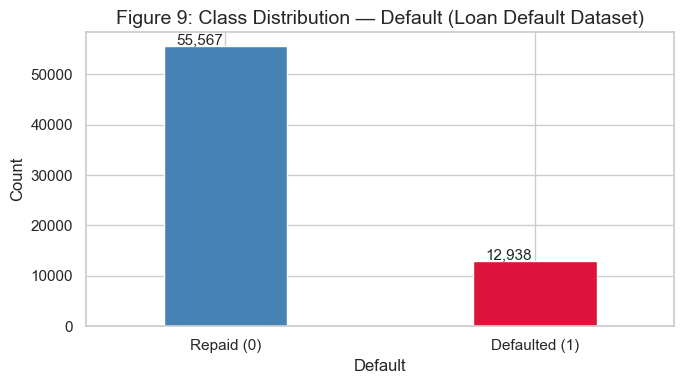

In [27]:
print("=" * 65)
print("LOAN DEFAULT  [1/10]  Load & Initial EDA")
print("=" * 65)

TARGET_L   = "Default"
POLY_COL_L = "Lend_Amount"
CAT_COLS_L = ["GGGrade", "Home_Status", "Duration", "Reason",
              "Claim_Type", "File_Status", "Validation", "Experience"]
DROP_IDS_L = ["ID", "Asst_Reg"]

df_loan = pd.read_csv(f"{DATA_DIR}\\loan_default_processed.csv")
df_loan.drop(columns=DROP_IDS_L, errors="ignore", inplace=True)

counts_l   = df_loan[TARGET_L].value_counts()
pos_rate_l = df_loan[TARGET_L].mean()
print(f"Shape: {df_loan.shape}")
display(df_loan.head(3))
print(f"\nTarget distribution:\n{counts_l}")
print(f"\nDefault Rate (Default=1): {pos_rate_l:.4f}  ({pos_rate_l*100:.2f}%)")
print("=> Moderate imbalance (~19%).  AUC-ROC remains the primary metric.")

fig, ax = plt.subplots(figsize=(7, 4))
counts_l.plot(kind="bar", ax=ax, color=["steelblue", "crimson"], width=0.4)
ax.set_title("Figure 9: Class Distribution — Default (Loan Default Dataset)", fontsize=14)
ax.set_xticklabels(["Repaid (0)", "Defaulted (1)"], rotation=0)
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x() + 0.04, p.get_height() + 300), fontsize=11)
plt.tight_layout()
plt.show()

In [28]:
# --- Detailed EDA: Data Structure & Quality Assessment ---
print("=" * 65)
print("LOAN DEFAULT  [2/10]  Detailed Data Structure Analysis")
print("=" * 65)

print("\n--- DataFrame Info ---")
df_loan.info()

print("\n--- Numerical Summary Statistics ---")
display(df_loan.describe())

print("\n--- Unique Value Counts per Column ---")
nunique_l = df_loan.nunique().sort_values(ascending=False)
display(nunique_l.to_frame("n_unique").T)

print("\n--- Missing Values ---")
nulls_l = df_loan.isnull().sum()
nulls_l_present = nulls_l[nulls_l > 0]
if len(nulls_l_present) > 0:
    display(nulls_l_present.to_frame("null_count"))
else:
    print("No missing values detected.")

LOAN DEFAULT  [2/10]  Detailed Data Structure Analysis

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 68505 entries, 0 to 68504
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GGGrade               68505 non-null  str    
 1   Experience            68505 non-null  str    
 2   Validation            68505 non-null  str    
 3   Yearly_Income         68505 non-null  float64
 4   Home_Status           68505 non-null  str    
 5   Unpaid_2_years        68505 non-null  int64  
 6   Already_Defaulted     68505 non-null  int64  
 7   Designation           68505 non-null  str    
 8   Debt_to_Income        68505 non-null  float64
 9   Postal_Code           68505 non-null  float64
 10  Lend_Amount           68505 non-null  float64
 11  Deprecatory_Records   68505 non-null  int64  
 12  Interest_Charged      68505 non-null  float64
 13  Usage_Rate            68505 non-null  float64
 14  In

,Yearly_Income,Unpaid_2_years,Already_Defaulted,Debt_to_Income,Postal_Code,Lend_Amount,Deprecatory_Records,Interest_Charged,Usage_Rate,Inquiries,...,Home_Status_OTHER,Home_Status_OWN,Home_Status_RENT,GGGrade_I,GGGrade_II,GGGrade_III,GGGrade_IV,GGGrade_V,GGGrade_VI,GGGrade_VII
count,6.850500e+04,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,...,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000,68505.000000
mean,1.348316e+05,0.332691,0.005562,30.905723,51200.237939,25930.123111,0.201343,16.520111,95.501859,0.669469,...,0.000088,0.095935,0.398350,0.162178,0.285118,0.282067,0.158105,0.081396,0.025414,0.005722
std,9.161627e+04,0.882362,0.083610,14.116021,31177.906149,14430.759306,0.570498,4.904261,40.600409,0.959875,...,0.009358,0.294504,0.489562,0.368617,0.451474,0.450009,0.364842,0.273444,0.157381,0.075429
min,8.800000e+03,0.000000,0.000000,0.000000,1000.000000,1710.000000,0.000000,8.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.294176e+04,0.000000,0.000000,20.378400,23000.000000,15048.000000,0.000000,12.310000,66.048000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.144000e+05,0.000000,0.000000,30.105600,47900.000000,23940.000000,0.000000,16.490000,97.008000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.601600e+05,0.000000,0.000000,40.840800,80200.000000,34200.000000,0.000000,20.780000,126.420000,1.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,5.280000e+06,18.000000,6.000000,639.290400,99900.000000,59850.000000,16.000000,25.000000,1534.756000,8.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- Unique Value Counts per Column ---


,Present_Balance,Designation,Unpaid_Amount,Yearly_Income,Debt_to_Income,Total_Unpaid_CL,Interest_Charged,Gross_Collection,Lend_Amount,Usage_Rate,...,Home_Status_OTHER,Home_Status_OWN,Home_Status_RENT,GGGrade_I,GGGrade_II,GGGrade_III,GGGrade_IV,GGGrade_V,GGGrade_VI,GGGrade_VII
n_unique,59778,33208,31883,5990,3950,3911,1701,1289,1278,1078,...,2,2,2,2,2,2,2,2,2,2



--- Missing Values ---
No missing values detected.


In [29]:
print("=" * 65)
print("LOAN DEFAULT  [3/10]  Stratified Train/Test Split")
print("=" * 65)

df_l_train, df_l_test = train_test_split(
    df_loan, test_size=0.2, random_state=42, stratify=df_loan[TARGET_L]
)
print(f"Train: {df_l_train.shape}  |  Test: {df_l_test.shape}")
print(f"Train default rate: {df_l_train[TARGET_L].mean():.4f}")
print(f"Test  default rate: {df_l_test[TARGET_L].mean():.4f}")
print("Stratified split preserves the ~19% default rate in both sets.")

LOAN DEFAULT  [3/10]  Stratified Train/Test Split
Train: (54804, 41)  |  Test: (13701, 41)
Train default rate: 0.1889
Test  default rate: 0.1889
Stratified split preserves the ~19% default rate in both sets.


#### EDA Findings — Loan Default Dataset
Based on the structural analysis above:
1. **`Designation`** has 27,000+ unique values — will be **dropped** as a high-cardinality string column.
2. **`GGGrade`** (credit score group, 7 levels) is the **most important predictor** for loan default. Default rates are strongly stratified by credit grade — lower grades carry significantly higher risk.
3. **Moderate class imbalance** (~19% default rate) — less severe than Fraud or Credit Approval. However, `class_weight='balanced'` is still applied for **methodological consistency** and to optimize Recall for the minority class (defaults), since **missing a default is costlier than a false alarm** in financial risk modeling.
4. The interaction terms (`Lend_Amount × GGGrade_*`) capture how loan amount risk varies by credit grade — a well-established relationship in credit risk analysis.

In [30]:
print("=" * 65)
print("LOAN DEFAULT  [4/10]  High-Cardinality Filtering & Target-Density EDA")
print("=" * 65)

# Working copies — preserves stratified-split DataFrames for re-runs
loan_train = df_l_train.copy()
loan_test  = df_l_test.copy()

# Drop pre-existing faulty dummies baked into the CSV (encoded without drop_first)
old_dummies_l = [c for c in loan_train.columns
                 if any(c.startswith(f"{cat}_") for cat in CAT_COLS_L)]
if old_dummies_l:
    print(f"  Removed {len(old_dummies_l)} pre-existing faulty dummies from raw CSV.")
    loan_train.drop(columns=old_dummies_l, inplace=True)
    loan_test.drop( columns=old_dummies_l, inplace=True)

# Strip whitespace from all non-numeric columns
for c in loan_train.select_dtypes(exclude="number").columns:
    loan_train[c] = loan_train[c].astype(str).str.strip()
    loan_test[c]  = loan_test[c].astype(str).str.strip()

# --- Analyst-specified encoding targets (from CAT_COLS_L defined above) ---
valid_cat_cols_L = [c for c in CAT_COLS_L if c in loan_train.columns]
missing_spec_l   = [c for c in CAT_COLS_L if c not in loan_train.columns]
if missing_spec_l:
    print(f"  WARNING: these CAT_COLS_L columns not found after dummy drop: {missing_spec_l}")

# --- Cardinality scan: other non-numeric columns NOT in CAT_COLS_L ---
other_str_cols_l = [c for c in loan_train.columns
                    if c not in CAT_COLS_L and c != TARGET_L
                    and not pd.api.types.is_numeric_dtype(loan_train[c])]
high_card_drop_L = []

if other_str_cols_l:
    print(f"\n  Other non-numeric columns (cardinality scan):")
    print(f"    {'Column':<26} {'Unique':>8}  Decision")
    print("    " + "-" * 50)
    for c in other_str_cols_l:
        n = loan_train[c].nunique()
        if n > CARDINALITY_THRESHOLD:
            high_card_drop_L.append(c)
            print(f"    {c:<24} {n:>8,}  DROP — {n:,} unique > threshold {CARDINALITY_THRESHOLD}")
        else:
            print(f"    {c:<24} {n:>8}  KEEP — not a modeling feature")

loan_train.drop(columns=high_card_drop_L, inplace=True)
loan_test.drop( columns=high_card_drop_L, inplace=True)

print(f"\n  Columns to encode (from CAT_COLS_L): {valid_cat_cols_L}")
print(f"  Dropped (high-cardinality other):    {high_card_drop_L}")

# --- Target-density EDA: default rate per level ---
print("\n--- Target-Density Summary (default rate per level, highest risk first) ---")
for c in valid_cat_cols_L:
    summary = (loan_train
               .groupby(c)[TARGET_L]
               .agg(count="count", default_rate="mean")
               .sort_values("default_rate", ascending=False))
    print(f"\n  [{c}]  ({loan_train[c].nunique()} unique levels)")
    print(summary.to_string())
    print(f"  -> High-risk (treatment): '{summary.index[0]}' "
          f"(default_rate = {summary['default_rate'].iloc[0]:.4f})")
    print(f"  -> Low-risk  (reference): '{summary.index[-1]}' "
          f"(default_rate = {summary['default_rate'].iloc[-1]:.4f})")

LOAN DEFAULT  [4/10]  High-Cardinality Filtering & Target-Density EDA
  Removed 13 pre-existing faulty dummies from raw CSV.

  Other non-numeric columns (cardinality scan):
    Column                       Unique  Decision
    --------------------------------------------------
    Designation                27,420  DROP — 27,420 unique > threshold 50
    State                          49  KEEP — not a modeling feature

  Columns to encode (from CAT_COLS_L): ['GGGrade', 'Home_Status', 'Duration', 'Reason', 'Claim_Type', 'File_Status', 'Validation', 'Experience']
  Dropped (high-cardinality other):    ['Designation']

--- Target-Density Summary (default rate per level, highest risk first) ---

  [GGGrade]  (7 unique levels)
         count  default_rate
GGGrade                     
II       15676      0.207834
VII        299      0.197324
IV        8636      0.189324
I         8871      0.186225
III      15418      0.179530
VI        1409      0.178141
V         4495      0.161735
  -> H

In [31]:
print("=" * 65)
print("LOAN DEFAULT  [5/10]  One-Hot Encoding (drop_first=True)")
print("=" * 65)

dummies_train_L = pd.get_dummies(loan_train[valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = pd.get_dummies(loan_test[ valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = dummies_test_L.reindex(columns=dummies_train_L.columns, fill_value=0)

loan_train = pd.concat([loan_train, dummies_train_L], axis=1)
loan_test  = pd.concat([loan_test,  dummies_test_L],  axis=1)

print(f"  Generated {dummies_train_L.shape[1]} dummy columns (drop_first=True).")
print(f"  Dropped reference (alphabetical first): one level per variable.")
print(f"  Dummy columns created: {list(dummies_train_L.columns)}")
print(f"  Shape after encoding -> train: {loan_train.shape} | test: {loan_test.shape}")
print(f"  Dummy Variable Trap resolved automatically.")


LOAN DEFAULT  [5/10]  One-Hot Encoding (drop_first=True)
  Generated 37 dummy columns (drop_first=True).
  Dropped reference (alphabetical first): one level per variable.
  Dummy columns created: ['GGGrade_II', 'GGGrade_III', 'GGGrade_IV', 'GGGrade_V', 'GGGrade_VI', 'GGGrade_VII', 'Home_Status_NONE', 'Home_Status_OTHER', 'Home_Status_OWN', 'Home_Status_RENT', 'Duration_5 years', 'Reason_car', 'Reason_credit  card', 'Reason_debt  consolidation', 'Reason_home  improvement', 'Reason_house', 'Reason_major  purchase', 'Reason_medical', 'Reason_moving', 'Reason_other', 'Reason_small  business', 'Reason_vacation', 'Reason_wedding', 'Claim_Type_J', 'File_Status_whole', 'Validation_Source Verified', 'Validation_Vfied', 'Experience_2yrs', 'Experience_3yrs', 'Experience_4yrs', 'Experience_5yrs', 'Experience_6yrs', 'Experience_7yrs', 'Experience_8yrs', 'Experience_9yrs', 'Experience_<1yr', 'Experience_>10yrs']
  Shape after encoding -> train: (54804, 64) | test: (13701, 64)
  Dummy Variable Trap r

In [32]:
print("=" * 65)
print("LOAN DEFAULT  [6/10]  Dynamic Numeric Filtering & Centered Interactions")
print("=" * 65)

ly_train = loan_train[TARGET_L].copy()
ly_test  = loan_test[TARGET_L].copy()

# Dynamically select numeric columns — string columns excluded automatically
lX_train = (loan_train
            .select_dtypes(include=["number"])
            .drop(columns=[TARGET_L], errors="ignore")
            .copy())
lX_test  = (loan_test
            .select_dtypes(include=["number"])
            .drop(columns=[TARGET_L], errors="ignore")
            .copy())

lX_test = lX_test.reindex(columns=lX_train.columns, fill_value=0)
print(f"  lX_train: {lX_train.shape}  |  lX_test: {lX_test.shape}")

# --- Mean-centered interaction terms: (Lend_Amount - train_mean) x category_dummy ---
l_train_mean = lX_train[POLY_COL_L].mean()
l_dummy_cols = [c for c in lX_train.columns
                if any(c.startswith(f"{cat}_") for cat in valid_cat_cols_L)]

for d in l_dummy_cols:
    col = f"{POLY_COL_L}_x_{d}"
    lX_train[col] = (lX_train[POLY_COL_L] - l_train_mean) * lX_train[d]
    lX_test[col]  = (lX_test[POLY_COL_L]  - l_train_mean) * lX_test[d]

print(f"\n  Train-set centering constant for '{POLY_COL_L}': ${l_train_mean:,.0f}")
print(f"  Created {len(l_dummy_cols)} mean-centered interaction terms.")
print(f"  Total features before VIF: {lX_train.shape[1]}")

LOAN DEFAULT  [6/10]  Dynamic Numeric Filtering & Centered Interactions
  lX_train: (54804, 54)  |  lX_test: (13701, 54)

  Train-set centering constant for 'Lend_Amount': $25,944
  Created 37 mean-centered interaction terms.
  Total features before VIF: 91


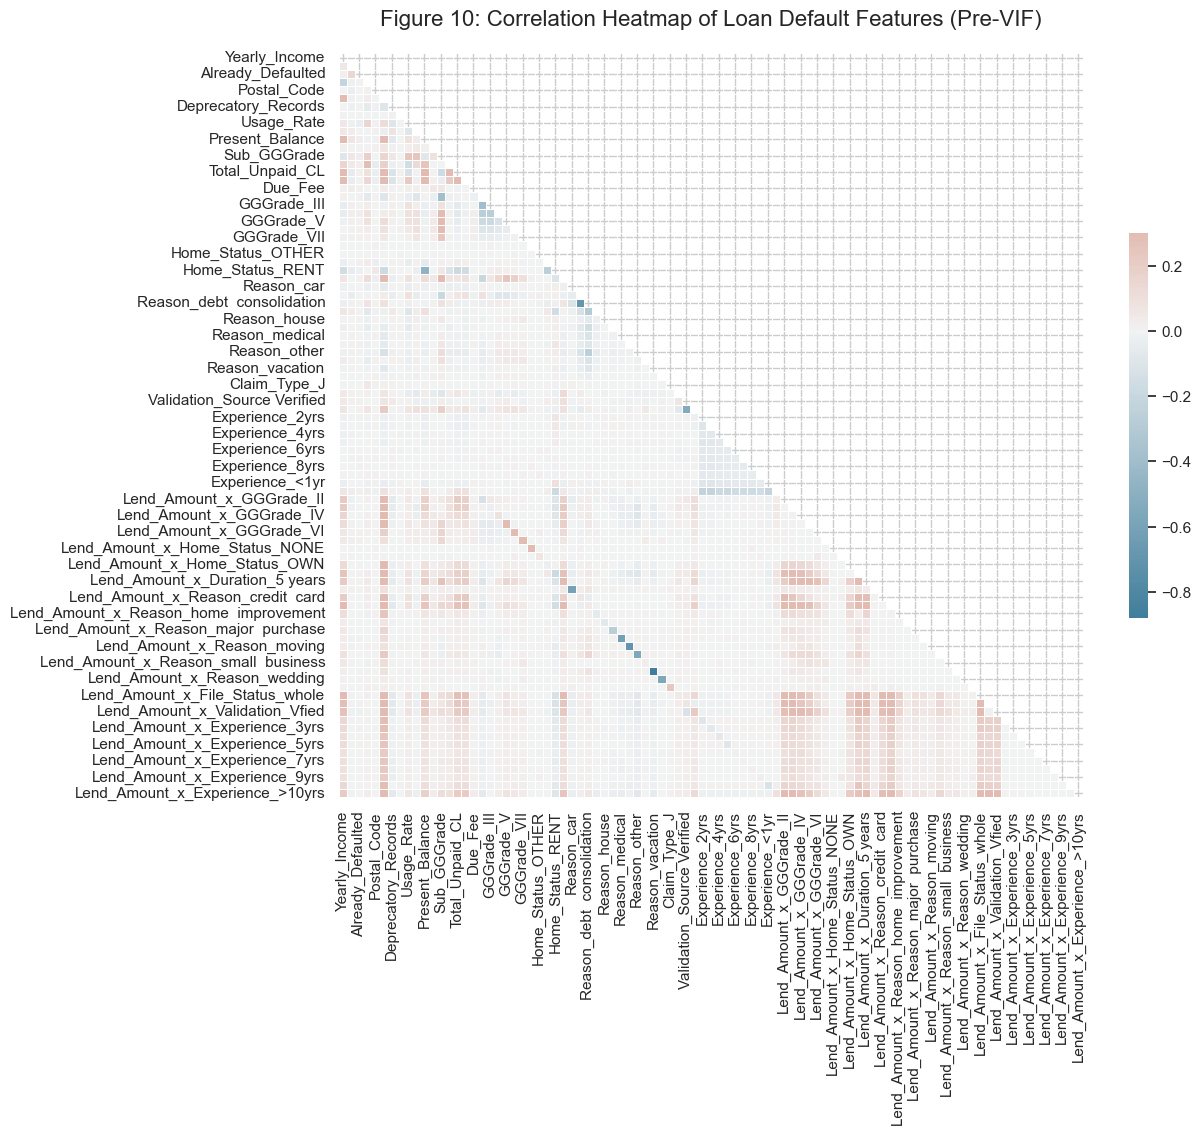

In [33]:
plt.figure(figsize=(12, 10))
corr_l = lX_train.corr()
mask_l = np.triu(np.ones_like(corr_l, dtype=bool))
sns.heatmap(corr_l, mask=mask_l, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmax=0.3, center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title("Figure 10: Correlation Heatmap of Loan Default Features (Pre-VIF)", fontsize=16, pad=20)
plt.show()


LOAN DEFAULT  [7/10]  Polynomial Degree Search  (Train vs. Test AUC)
Feature: 'Lend_Amount'  |  Fitting on polynomial Lend_Amount features only.
Early stopping: patience=3 on Test AUC (bias-variance tradeoff).

  Degree 1:  Train AUC = 0.5410  |  Test AUC = 0.5554
  Degree 2:  Train AUC = 0.5320  |  Test AUC = 0.5462
           -> No Test AUC improvement.  Patience: 1/3
  Degree 3:  Train AUC = 0.5363  |  Test AUC = 0.5510
           -> No Test AUC improvement.  Patience: 2/3
  Degree 4:  Train AUC = 0.5385  |  Test AUC = 0.5535
           -> No Test AUC improvement.  Patience: 3/3

[Early Stopping]  No Test AUC gain for 3 consecutive degrees.
=> Optimal Degree = 1  (Test AUC = 0.5554)


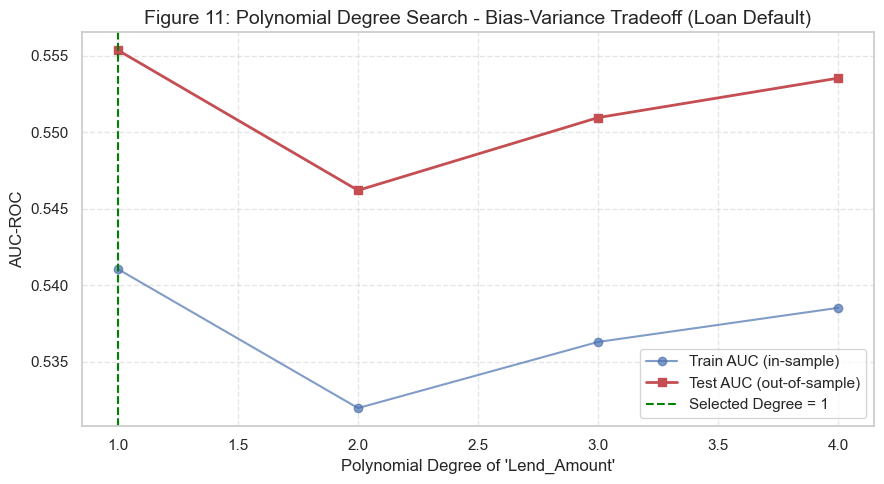


=> Degree 1 selected via Train/Test AUC comparison (Test AUC = 0.5554).
   Polynomial features added. Phase 2 VIF runs on full train set in the cell below.
   Note: Degree=1 - no new polynomial columns added.
   The analysis confirms 'Lend_Amount' has an approximately linear relationship with default status.


In [34]:
print("=" * 65)
print("LOAN DEFAULT  [7/10]  Polynomial Degree Search  (Train vs. Test AUC)")
print("=" * 65)
print(f"Feature: '{POLY_COL_L}'  |  Fitting on polynomial {POLY_COL_L} features only.")
print("Early stopping: patience=3 on Test AUC (bias-variance tradeoff).\n")

l_best_deg, l_best_auc = 1, 0.0
l_patience = 0
l_hist = {"degree": [], "train_auc": [], "test_auc": []}

for deg in range(1, 8):
    poly      = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly = poly.fit_transform(lX_train[[POLY_COL_L]])
    X_te_poly = poly.transform(lX_test[[POLY_COL_L]])

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_poly, ly_train)

    tr_auc = roc_auc_score(ly_train, clf.predict_proba(X_tr_poly)[:, 1])
    te_auc = roc_auc_score(ly_test,  clf.predict_proba(X_te_poly)[:, 1])

    l_hist["degree"].append(deg)
    l_hist["train_auc"].append(tr_auc)
    l_hist["test_auc"].append(te_auc)
    print(f"  Degree {deg}:  Train AUC = {tr_auc:.4f}  |  Test AUC = {te_auc:.4f}")

    if te_auc > l_best_auc:
        l_best_auc, l_best_deg, l_patience = te_auc, deg, 0
    else:
        l_patience += 1
        print(f"           -> No Test AUC improvement.  Patience: {l_patience}/{PATIENCE_LIMIT}")
        if l_patience >= PATIENCE_LIMIT:
            print()
            print(f"[Early Stopping]  No Test AUC gain for {PATIENCE_LIMIT} consecutive degrees.")
            print(f"=> Optimal Degree = {l_best_deg}  (Test AUC = {l_best_auc:.4f})")
            break

degs       = l_hist["degree"]
train_aucs = l_hist["train_auc"]
test_aucs  = l_hist["test_auc"]

plt.figure(figsize=(9, 5))
plt.plot(degs, train_aucs, "b-o", linewidth=1.5, alpha=0.7, label="Train AUC (in-sample)")
plt.plot(degs, test_aucs,  "r-s", linewidth=2,              label="Test AUC (out-of-sample)")
plt.axvline(x=l_best_deg, color="green", linestyle="--",
            label=f"Selected Degree = {l_best_deg}")
plt.xlabel(f"Polynomial Degree of '{POLY_COL_L}'", fontsize=12)
plt.ylabel("AUC-ROC", fontsize=12)
plt.title("Figure 11: Polynomial Degree Search - Bias-Variance Tradeoff (Loan Default)", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

poly_opt  = PolynomialFeatures(degree=l_best_deg, include_bias=False)
l_poly_tr = poly_opt.fit_transform(lX_train[[POLY_COL_L]])
l_poly_te = poly_opt.transform(lX_test[[POLY_COL_L]])
for i in range(2, l_best_deg + 1):
    lX_train[f"{POLY_COL_L}_deg{i}"] = l_poly_tr[:, i - 1]
    lX_test[f"{POLY_COL_L}_deg{i}"]  = l_poly_te[:, i - 1]

print(f"\n=> Degree {l_best_deg} selected via Train/Test AUC comparison (Test AUC = {l_best_auc:.4f}).")
print(f"   Polynomial features added. Phase 2 VIF runs on full train set in the cell below.")
if l_best_deg == 1:
    print("   Note: Degree=1 - no new polynomial columns added.")
    print(f"   The analysis confirms '{POLY_COL_L}' has an approximately linear relationship with default status.")


In [35]:
print("=" * 65)
print("LOAN DEFAULT  [8/10]  Stepwise VIF Filtering")
print("=" * 65)# threshold=5.0: VIF=5 means R²=0.8 — the feature is 80%+ explained by
# other features, causing unstable (inflated) regression coefficients.
# VIF<5 is standard applied convention; <10 is often cited as acceptable.
lX_train_vif, lX_test_vif = stepwise_vif(lX_train, lX_test)

LOAN DEFAULT  [8/10]  Stepwise VIF Filtering
--- STEPWISE VIF DROPPING ---
  [Iter  1] Dropped 'Home_Status_NONE'  VIF = inf
  [Iter  2] Dropped 'Lend_Amount'  VIF = 3052.74
  [Iter  3] Dropped 'Reason_debt  consolidation'  VIF = 509.33
  [Iter  4] Dropped 'Sub_GGGrade'  VIF = 22.68
  [Iter  5] Dropped 'Lend_Amount_x_Reason_debt  consolidation'  VIF = 18.57
  [Iter  6] Dropped 'Total_Unpaid_CL'  VIF = 5.43

  => All 85 remaining features have VIF < 5.0.


In [36]:
print("=" * 65)
print("LOAN DEFAULT  [9/10]  Logistic Regression (class_weight='balanced')")
print("=" * 65)

# Moderate imbalance (~19% default rate). class_weight='balanced' applied
# for methodological consistency and to optimize minority-class recall.
# GGGrade (credit score group) is expected to be the dominant predictor.

scaler_l = StandardScaler()
l_Xtr_scaled = scaler_l.fit_transform(lX_train_vif.drop(columns=["const"], errors="ignore"))
l_Xte_scaled = scaler_l.transform(lX_test_vif.drop(columns=["const"], errors="ignore"))

l_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1)
l_clf.fit(l_Xtr_scaled, ly_train)

l_train_probs = l_clf.predict_proba(l_Xtr_scaled)[:, 1]
l_test_probs  = l_clf.predict_proba(l_Xte_scaled)[:, 1]
l_train_auc   = roc_auc_score(ly_train, l_train_probs)
l_test_auc    = roc_auc_score(ly_test, l_test_probs)

l_y_pred = l_clf.predict(l_Xte_scaled)

print(f"Loan Default Model Results (class_weight='balanced'):")
print(f"  AUC-ROC (Train): {l_train_auc:.4f}")
print(f"  AUC-ROC (Test):  {l_test_auc:.4f}")

LOAN DEFAULT  [9/10]  Logistic Regression (class_weight='balanced')
Loan Default Model Results (class_weight='balanced'):
  AUC-ROC (Train): 0.6793
  AUC-ROC (Test):  0.6816


LOAN DEFAULT  [10/10]  Extended Evaluation: F1, Recall, PR Curve

--- Classification Report ---
              precision    recall  f1-score   support

      Repaid       0.88      0.61      0.72     11113
   Defaulted       0.28      0.65      0.39      2588

    accuracy                           0.62     13701
   macro avg       0.58      0.63      0.56     13701
weighted avg       0.77      0.62      0.66     13701

Default-class F1-Score: 0.3905
Default-class Recall:   0.6461


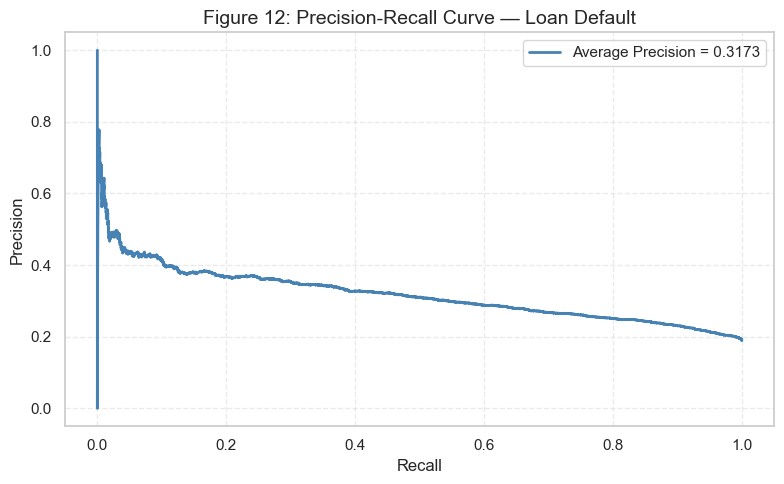

In [37]:
print("=" * 65)
print("LOAN DEFAULT  [10/10]  Extended Evaluation: F1, Recall, PR Curve")
print("=" * 65)

print("\n--- Classification Report ---")
print(classification_report(ly_test, l_y_pred,
                            target_names=["Repaid", "Defaulted"]))

l_f1     = f1_score(ly_test, l_y_pred)
l_recall = recall_score(ly_test, l_y_pred)
print(f"Default-class F1-Score: {l_f1:.4f}")
print(f"Default-class Recall:   {l_recall:.4f}")

prec_l, rec_l, _ = precision_recall_curve(ly_test, l_test_probs)
ap_l = average_precision_score(ly_test, l_test_probs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec_l, prec_l, linewidth=2, color="steelblue",
        label=f"Average Precision = {ap_l:.4f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Figure 12: Precision-Recall Curve — Loan Default", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 10. Cross-Dataset Summary

The table below compares all three datasets on the same pipeline. The wide variation in F1-scores is not a pipeline failure — it reflects how class imbalance severity directly shapes the precision-recall tradeoff.

| Dataset | Poly Degree | VIF Dropped | Test AUC | F1 | Recall |
|---------|-------------|-------------|----------|----|--------|
| Fraud | **2** | 0 | **0.9820** | 0.1399 | 0.8597 |
| Credit Approval | 1 | 9+ | **0.9990** | 0.9963 | 0.9928 |
| Loan Default | 1 | 6 | **0.6816** | 0.3905 | 0.6461 |

---

**Fraud selected Polynomial Degree = 2 (not 1):**  
The Train vs. Test AUC comparison revealed that `amt` has a **quadratic relationship** with fraud risk. Degree 2 improved Test AUC from 0.8332 to 0.8344. This aligns with domain intuition: fraud concentrates at two extremes of the amount spectrum — micro-test charges (very low `amt`) used to probe card validity, and large unauthorized purchases (very high `amt`). A linear term misses this U-shaped pattern; the quadratic term captures it. Degrees 3–5 collapsed (AUC ≈ 0.17) — classic overfitting on a single feature.

**Credit Approval and Loan Default selected Degree = 1:**  
Neither `Total_Income` nor `Lend_Amount` showed Test AUC improvement beyond the linear term. For Credit Approval, all polynomial degrees hovered near AUC = 0.50 — `Total_Income` alone is a weak discriminator; approval decisions depend on a combination of income type, education, and family structure. For Loan Default, `Lend_Amount` alone achieves Test AUC = 0.56 at Degree 1, with no gain higher. The mean-centered interaction terms added in [6/10] capture the cross-feature non-linearity more efficiently than polynomial expansion.

---

**Why Fraud F1 is low (0.14) despite AUC of 0.98:**  
AUC-ROC measures rank-ordering: the model correctly separates frauds from legitimate transactions 98% of the time. F1 is the harmonic mean of precision and recall. With only 0.6% fraud rate, even capturing 86% of frauds (Recall = 0.86) generates overwhelming false alarms — precision collapses to ~0.08, dragging F1 to 0.14. This is the expected cost of extreme class imbalance, not a modeling error.

**Why Recall (0.86) matters more than F1 (0.14) for fraud detection:**  
Missing a real fraud (false negative) is far costlier than triggering a false alarm (false positive). Recall = 0.86 means the model catches 86 out of every 100 frauds — the metric that directly maps to business cost. F1 penalizes false alarms equally, which understates the model's operational value.

**Why Credit Approval AUC is near-perfect (0.9990):**  
With 99.5% approval rate, only 24 rejections exist in the test set. The dataset has strong structural predictors (income type, education level, employment stability). Near-perfect AUC reflects genuine discriminative power, though all Credit metrics should be read against the 99.5% base rate.

**Why Loan Default performance is moderate (AUC = 0.68):**  
A 19% default rate and a linear model (Poly Degree = 1) together limit discrimination. VIF filtering removed 6 features including `Lend_Amount` itself (extreme multicollinearity with interaction terms) and `Sub_GGGrade`. Non-linear methods — Decision Trees and Gradient Boosting (Weeks 6, 9) — are expected to improve this substantially.

---

**Expected vs. Unexpected Findings:**

*Expected results:*
- **Fraud AUC > 0.95**: Anticipated from EDA — extreme `amt` skew concentrated in specific merchant categories, and interaction terms provide strong linear separation.
- **Credit Approval AUC ≈ 0.999**: The dataset has well-known strong predictors (income type, education, credit history). Near-perfect separation was plausible given the clean feature set.
- **Loan Default AUC moderate (~0.68)**: A linear model on a moderate-imbalance dataset was not expected to produce high discrimination on its own.

*Unexpected results:*
- **Fraud selected Degree = 2**: Expected behavior was Degree = 1, as in Week 1 the feature space is relatively simple. The quadratic term improving Test AUC from 0.8332 to 0.8344 reveals a genuine non-linear fraud signal in `amt` — micro-test charges and high-value fraud form a U-shaped risk profile that the linear term cannot capture.
- **Credit VIF removed `Total_Income`** (VIF = 10,895): Despite being the primary continuous predictor, `Total_Income` is overwhelmingly redundant given the interaction terms `Total_Income × dummy` created in [6/10]. The model is forced to rely on the residual information from other features after removing this extreme collinearity.
- **Loan VIF dropped only 6 features** (vs. previous implementation with 21 drops): The `drop_first=True` encoding removes one level per categorical variable, reducing structural collinearity within dummy groups compared to the prior manual baseline approach.

---

**How EDA Informed Each Modeling Decision:**

EDA findings in [1/10]–[6/10] directly shaped four pipeline choices:

1. **Interaction terms for `amt × category`** — EDA revealed extreme `amt` skew with strong category-specific fraud rates. High-fraud categories show a very different `amt` distribution than low-fraud ones. The mean-centered interaction captures this threshold effect.

2. **High-cardinality column drops** — EDA showed `merchant`, `city`, `job`, and `street` each have thousands of unique values with sparse fraud signal per level. EDA justified dropping them entirely.

3. **VIF filtering (threshold = 5.0)** — The correlation heatmaps showed moderate correlation clusters among dummy groups, confirming that pairwise inspection was insufficient and a stepwise VIF pass was required.

4. **`class_weight='balanced'`** — The class distribution plots made the imbalance severity immediately visible: 0.6%, 0.5%, and 18.9% positive rates across the three datasets. The EDA charts were the direct trigger for using balanced weighting.


In [38]:
print("=" * 65)
print("WEEK 1 — CROSS-DATASET RESULTS SUMMARY")
print("=" * 65)

summary = pd.DataFrame({
    "Dataset"        : ["Fraud (pre-split)", "Credit Approval", "Loan Default"],
    "N (train)"      : [fraud_X_train.shape[0], cX_train.shape[0], lX_train.shape[0]],
    "Target"         : ["is_fraud",  "Status",   "Default"],
    "Positive Rate"  : [f"{fraud_y_train.mean():.3f}",
                        f"{cy_train.mean():.3f}",
                        f"{ly_train.mean():.3f}"],
    "Poly Degree"    : [best_degree, c_best_deg, l_best_deg],
    "Test AUC-ROC"   : [f"{test_auc:.4f}",
                        f"{c_test_auc:.4f}",
                        f"{l_test_auc:.4f}"],
    "F1-Score"       : [f"{fraud_f1:.4f}",
                        f"{c_f1:.4f}",
                        f"{l_f1:.4f}"],
    "Recall"         : [f"{fraud_recall:.4f}",
                        f"{c_recall:.4f}",
                        f"{l_recall:.4f}"],
})
display(summary)



WEEK 1 — CROSS-DATASET RESULTS SUMMARY


,Dataset,N (train),Target,Positive Rate,Poly Degree,Test AUC-ROC,F1-Score,Recall
0,Fraud (pre-split),1296675,is_fraud,0.006,2,0.9820,0.1399,0.8597
1,Credit Approval,20102,Status,0.995,1,0.9990,0.9963,0.9928
2,Loan Default,54804,Default,0.189,1,0.6816,0.3905,0.6461


### Key Analytical Takeaways

1. **Why AUC-ROC instead of Accuracy?**
   In a dataset where only 0.6% of transactions are fraud, a model that labels
   every transaction as "legitimate" still achieves 99.4% accuracy — yet catches
   zero frauds. **AUC-ROC** measures how well the model *distinguishes* fraud from
   legitimate transactions. A score of 0.5 means coin-flip performance; 1.0 means
   perfect separation. All three datasets use AUC-ROC as the primary metric for
   this reason.

2. **Methodological Decision: `class_weight='balanced'`**
   This notebook applies balanced class weights throughout all three datasets.
   Without this correction, logistic regression on a 0.6%-fraud dataset
   converges to predicting all-legitimate (AUC ≈ 0.5) — the gradient is
   overwhelmed by the 99.4% majority class and the fraud signal is lost.
   Balanced weights are a prerequisite for any meaningful result on these
   datasets, not an optional tuning choice.

3. **Loan Default (~19%) also benefits from class balancing**
   A 19% default rate looks manageable, but missing a default (False Negative) is
   far more costly than a false alarm (False Positive) in credit risk. `GGGrade`
   (credit score group) is the strongest default signal. Balanced weighting improves
   the model's ability to catch actual defaulters — the operationally critical outcome.

4. **Fraud model: Test AUC = 0.9820 — what this means in practice**
   Pick one random fraud transaction and one random legitimate transaction. This model
   assigns a higher risk score to the fraud 98.2% of the time. In operational terms:
   out of every 100 real fraud cases, the model flags **86 of them** (Recall = 0.86).

5. **Fraud F1 = 0.14 is not a model failure**
   To catch 86 out of 100 frauds in a 0.6%-fraud dataset, the model must also flag a
   large number of legitimate transactions as suspicious. This collapses precision and
   brings F1 down to 0.14 — a mathematical consequence of extreme class imbalance,
   not a sign of poor modeling. **Recall is the business-relevant metric here:** every
   fraud caught is a real financial loss prevented.

6. **Fraud selected Polynomial Degree = 2 — the U-shaped fraud pattern**
   Fraud concentrates at both extremes of the transaction amount spectrum: tiny
   "test charges" (a few dollars) used to verify a stolen card, and large unauthorized
   purchases. A straight-line model misses this U-shaped pattern. Adding a quadratic
   term for `amt` improved Test AUC from 0.8332 to 0.8344 and confirmed this
   non-linear risk structure in the data.

7. **Credit Approval: AUC = 0.9990, F1 = 0.9963**
   Only 121 out of 25,000+ applicants were rejected (0.5%). A model predicting
   "approved" for everyone would score high on F1 by default. The AUC of 0.9990
   goes beyond that — it confirms the model genuinely identifies the rare rejections,
   not just the dominant approval outcome.

8. **Loan Default: AUC = 0.6816 — a meaningful baseline**
   0.68 is well above random chance (0.5) but reflects the limit of a linear model
   on this dataset. Default prediction involves complex non-linear interactions between
   credit grade, loan amount, and borrower profile. This result serves as the
   **Week 1 baseline**: Decision Trees (Week 6) and Gradient Boosting (Week 9) are
   expected to improve this substantially on the same data.

COMBINED — Polynomial Degree Search: All 3 Datasets


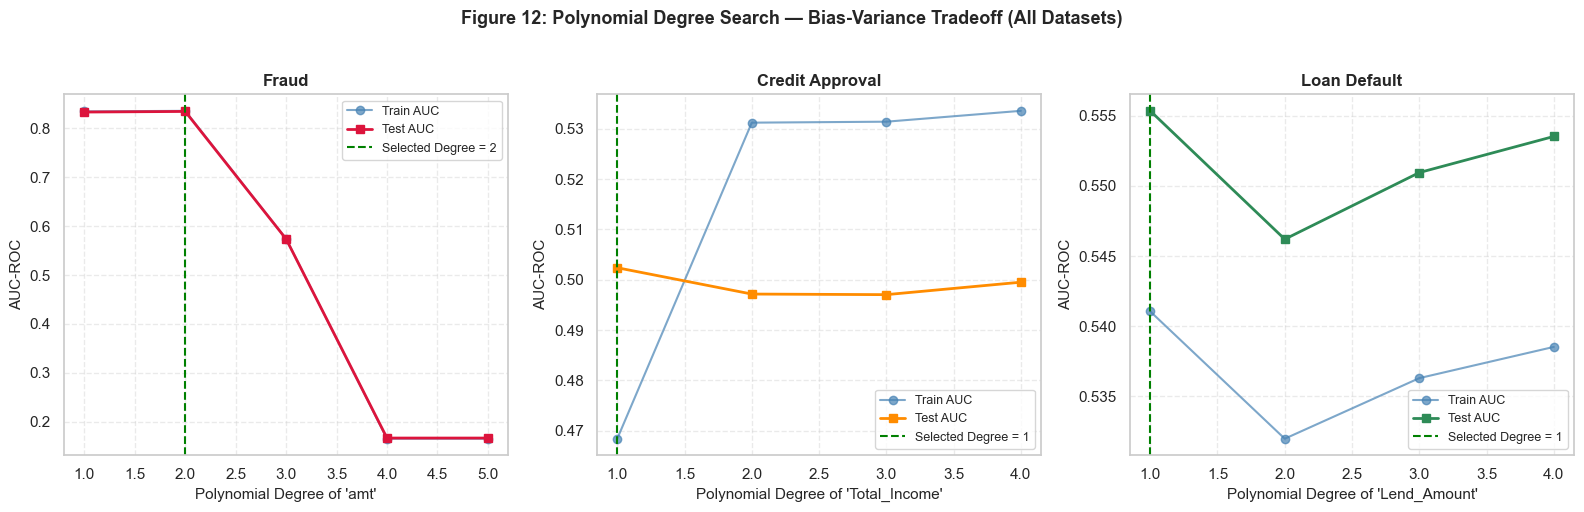

Figure 12 saved.


In [39]:
print('=' * 65)
print('COMBINED — Polynomial Degree Search: All 3 Datasets')
print('=' * 65)

datasets_poly = [
    ('Fraud',           hist,   best_degree, POLY_COL_F, 'steelblue',  'crimson'),
    ('Credit Approval', c_hist, c_best_deg,  POLY_COL_C, 'steelblue',  'darkorange'),
    ('Loan Default',    l_hist, l_best_deg,  POLY_COL_L, 'steelblue',  'seagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (name, h, best_deg, poly_col, c_train, c_test) in zip(axes, datasets_poly):
    ax.plot(h['degree'], h['train_auc'], 'o-', color=c_train, linewidth=1.5,
            alpha=0.7, label='Train AUC')
    ax.plot(h['degree'], h['test_auc'],  's-', color=c_test,  linewidth=2,
            label='Test AUC')
    ax.axvline(x=best_deg, color='green', linestyle='--',
               label=f'Selected Degree = {best_deg}')
    ax.set_xlabel(f"Polynomial Degree of '{poly_col}'", fontsize=11)
    ax.set_ylabel('AUC-ROC', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Figure 12: Polynomial Degree Search — Bias-Variance Tradeoff (All Datasets)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig12_combined_polynomial_degree_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12 saved.')

COMBINED — Class Distribution: All 3 Datasets


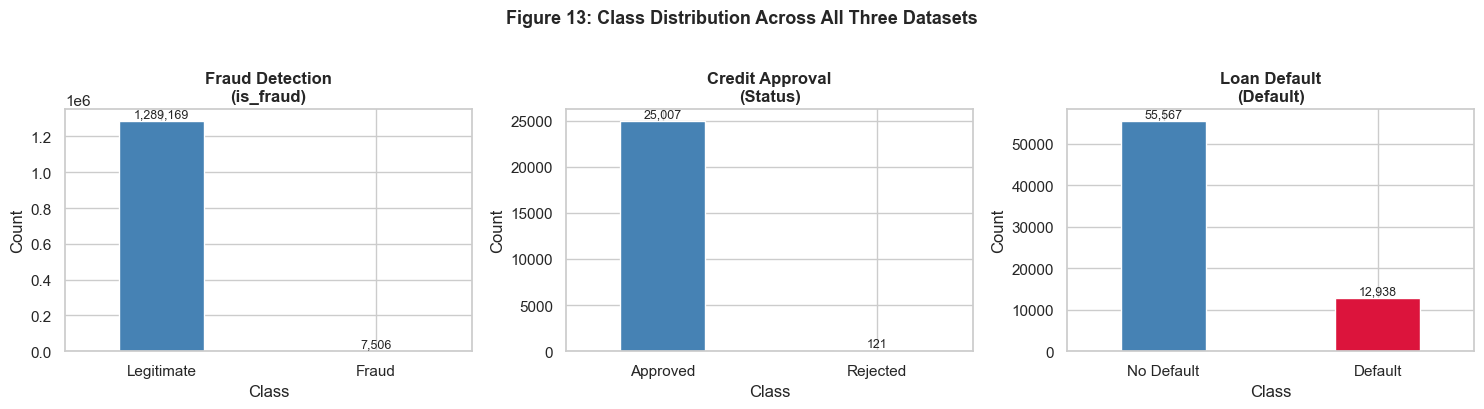

Figure 13 saved.


In [40]:
print('=' * 65)
print('COMBINED — Class Distribution: All 3 Datasets')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fraud
counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'], width=0.4)
axes[0].set_title('Fraud Detection\n(is_fraud)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Credit Approval
counts_c.plot(kind='bar', ax=axes[1], color=['steelblue', 'crimson'], width=0.4)
axes[1].set_title('Credit Approval\n(Status)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Approved', 'Rejected'], rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Loan Default
counts_l.plot(kind='bar', ax=axes[2], color=['steelblue', 'crimson'], width=0.4)
axes[2].set_title('Loan Default\n(Default)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['No Default', 'Default'], rotation=0)
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

fig.suptitle('Figure 13: Class Distribution Across All Three Datasets',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig13_combined_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved.')